In [2]:
# import dependencies

import yfinance as yf
import os
import inspect
import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.stats import norm
from datetime import date, datetime
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time
import re
import warnings
warnings.filterwarnings("ignore")

In [3]:
# data manager

# ---------------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------------

TICKERS            = ["NFLX", "SPOT", "DIS"]
INCEPTION_DATE     = "2025-04-02"
RISK_FREE_RATE     = 0.05
ROLLING_VOL_WINDOW = 252

# Official fixing prices from UBS Termsheet (ISIN CH1431536452)
INITIAL_FIXING_PRICES = {
    "NFLX": 93.55,
    "SPOT": 565.41,
    "DIS":  97.88,
}

_DEFAULT_DATA_ROOT   = os.path.join(os.getcwd(), "..", "..", "final_dataset")
_LOG_RETURNS_RELPATH = os.path.join("prices", "fetch_prices_v1", "processed", "log_returns.csv")
_BS_SURFACE_RELPATH  = os.path.join("synthetic_option", "black_scholes", "all_bs_surfaces.csv")
_HST_SURFACE_RELPATH = os.path.join("synthetic_option", "heston", "all_heston_surfaces.csv")


def resolve_paths(data_root: str = None) -> dict:
    root = (data_root or os.environ.get("DATA_ROOT") or _DEFAULT_DATA_ROOT)
    root = os.path.abspath(root)
    return {
        "root":        root,
        "log_returns": os.path.join(root, _LOG_RETURNS_RELPATH),
        "bs_surface":  os.path.join(root, _BS_SURFACE_RELPATH),
        "hst_surface": os.path.join(root, _HST_SURFACE_RELPATH),
    }


# ---------------------------------------------------------------------------
# DataStore  (model-agnostic)
# ---------------------------------------------------------------------------

@dataclass
class DataStore:
    correlation_matrix:       np.ndarray   = field(default_factory=lambda: np.eye(3))
    log_returns:              pd.DataFrame = field(default_factory=pd.DataFrame)
    realised_spots:           pd.DataFrame = field(default_factory=pd.DataFrame)
    inception_surface:        pd.DataFrame = field(default_factory=pd.DataFrame)
    live_surface:             pd.DataFrame = field(default_factory=pd.DataFrame)
    rolling_vol:              pd.DataFrame = field(default_factory=pd.DataFrame)
    model_params:             Dict         = field(default_factory=dict)   # generic
    daily_params:             Dict         = field(default_factory=dict)   # generic
    terminal_model_params:    Dict         = field(default_factory=dict)   # generic
    initial_fixing_prices:    Dict         = field(default_factory=dict)
    surface_type:             str          = "bs"
    today:                    str          = field(default_factory=lambda: date.today().isoformat())
    historical_brc_prices:    pd.Series    = field(default_factory=pd.Series)
    treasury_curve:           pd.DataFrame = field(default_factory=pd.DataFrame)
    historical_iv:            pd.DataFrame = field(default_factory=pd.DataFrame)

    # ------------------------------------------------------------------
    # Back-compat aliases for code that still uses the Heston-era names.
    # These delegate to the generic model_params / terminal_model_params dicts
    # so existing callers (stage6_backtest, main.py terminal section, etc.)
    # continue to work without changes.
    # ------------------------------------------------------------------

    @property
    def inception_heston_params(self) -> Dict:
        return self.model_params

    @inception_heston_params.setter
    def inception_heston_params(self, v):
        self.model_params = v

    @property
    def terminal_heston_params(self) -> Dict:
        return self.terminal_model_params

    @terminal_heston_params.setter
    def terminal_heston_params(self, v):
        self.terminal_model_params = v


# ---------------------------------------------------------------------------
# Black-Scholes helpers  (IV extraction only — not model-specific)
# ---------------------------------------------------------------------------

def _bs_call(S, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return max(0.0, S - K)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def _bs_put(S, K, T, r, sigma):
    return _bs_call(S, K, T, r, sigma) - S + K * np.exp(-r * T)


def _implied_vol(market_price, S, K, T, r, option_type="call"):
    if T <= 0 or market_price <= 0:
        return np.nan
    intrinsic = max(0.0, S - K) if option_type == "call" else max(0.0, K - S)
    if market_price < intrinsic - 1e-4:
        return np.nan
    fn = (lambda s: _bs_call(S, K, T, r, s) - market_price
          if option_type == "call"
          else _bs_put(S, K, T, r, s) - market_price)
    try:
        return brentq(fn, 1e-4, 5.0, xtol=1e-6, maxiter=200)
    except Exception:
        return np.nan


# ---------------------------------------------------------------------------
# Historical BRC prices
# ---------------------------------------------------------------------------

def load_historical_brc_prices(path: str = "../../historical_BRC_prices.txt") -> pd.Series:
    script_dir = os.getcwd()
    candidates = [
        path,
        os.path.join(script_dir, "../../historical_BRC_prices.txt"),
        os.path.join(script_dir, "../../../historical_BRC_prices.txt"),
        "/mnt/user-data/uploads/historical_BRC_prices.txt",
    ]
    raw = None
    for p in candidates:
        try:
            with open(p) as f:
                raw = f.read()
            print(f"  Loaded historical BRC prices from: {p}")
            break
        except FileNotFoundError:
            continue
    if raw is None:
        print(f"  WARNING: historical BRC prices not found")
        return pd.Series(dtype=float)

    pattern = r'\{\s*"date"\s*:\s*(\d+)\s*,\s*"value"\s*:\s*([\d.]+)\s*\}'
    matches = re.findall(pattern, raw)
    if not matches:
        print(f"  WARNING: no price records parsed from {path}")
        return pd.Series(dtype=float)

    records = [(pd.Timestamp(int(ts), unit="ms").normalize(), float(val))
               for ts, val in matches]
    s = pd.Series({dt: val for dt, val in records}, name="ubs_brc_price")
    s.index = pd.DatetimeIndex(s.index)
    s = s.sort_index()
    print(f"  Historical BRC prices: {len(s)} records "
          f"({s.index[0].date()} → {s.index[-1].date()})")
    return s


# ---------------------------------------------------------------------------
# Treasury yield curve
# ---------------------------------------------------------------------------

_TREASURY_TENORS = {
    "1_month": 1/12, "2_month": 2/12, "3_month": 3/12, "6_month": 6/12,
    "1_year": 1.0, "2_year": 2.0, "3_year": 3.0, "5_year": 5.0,
    "7_year": 7.0, "10_year": 10.0, "20_year": 20.0,
}
_TENOR_YEARS = list(_TREASURY_TENORS.values())
_TENOR_COLS  = list(_TREASURY_TENORS.keys())


def load_treasury_curve(path: str) -> pd.DataFrame:
    script_dir = os.getcwd()
    candidates = [
        path,
        os.path.join(script_dir, "../../treasury_curve.csv"),
        os.path.join(script_dir, "../../../treasury_curve.csv"),
        "/mnt/user-data/uploads/treasury_curve.csv",
    ]
    raw = None
    used_path = None
    for p in candidates:
        try:
            raw = pd.read_csv(p)
            used_path = p
            break
        except FileNotFoundError:
            continue

    if raw is None:
        print("  WARNING: treasury curve CSV not found — falling back to flat rate.")
        return pd.DataFrame()

    date_col = next((c for c in raw.columns
                     if c.strip().lower() in ("date", "dates", "index")), None)
    if date_col is None:
        date_col = raw.columns[0]

    try:
        raw[date_col] = pd.to_datetime(raw[date_col], infer_datetime_format=True,
                                    errors="coerce")
    except TypeError:
        raw[date_col] = pd.to_datetime(raw[date_col], errors="coerce")

    raw = raw.dropna(subset=[date_col])
    df  = raw.set_index(date_col).copy()
    df.index = pd.DatetimeIndex(df.index).normalize()
    df.index.name = "date"
    df = df.sort_index()

    present = [c for c in _TENOR_COLS if c in df.columns]
    if not present:
        return pd.DataFrame()
    df = df[present].apply(pd.to_numeric, errors="coerce").copy()
    if df.max().max() > 1.0:
        df = df / 100.0

    print(f"  Treasury curve loaded: {used_path}  ({len(df)} rows)")
    return df


def load_historical_iv(path: str) -> pd.DataFrame:
    script_dir = os.getcwd()
    candidates = [
        path,
        os.path.join(script_dir, "../../historical_iv.csv"),
        os.path.join(script_dir, "../../../historical_iv.csv"),
        "/mnt/user-data/uploads/historical_iv.csv",
    ]
    raw = None
    used_path = None
    for p in candidates:
        try:
            raw = pd.read_csv(p)
            used_path = p
            break
        except FileNotFoundError:
            continue

    if raw is None:
        print("  historical_iv.csv not found — will use realised vol only.")
        return pd.DataFrame()

    raw.columns = [c.strip().lower() for c in raw.columns]
    date_col   = next((c for c in raw.columns if "date" in c), None)
    ticker_col = next((c for c in raw.columns
                       if c in ("act_symbol", "symbol", "ticker")), None)
    vol_col    = next((c for c in raw.columns if "iv" in c or "vol" in c), None)

    if not all([date_col, ticker_col, vol_col]):
        print(f"  WARNING: historical_iv.csv missing expected columns. "
              f"Found: {list(raw.columns)}")
        return pd.DataFrame()

    raw[date_col] = pd.to_datetime(raw[date_col], errors="coerce")
    raw = raw.dropna(subset=[date_col])
    raw[vol_col]  = pd.to_numeric(raw[vol_col], errors="coerce")
    raw = raw[raw[vol_col] > 0].dropna(subset=[vol_col])
    if raw[vol_col].median() > 1.0:
        raw[vol_col] = raw[vol_col] / 100.0

    wide = (raw.pivot_table(index=date_col, columns=ticker_col,
                             values=vol_col, aggfunc="mean")
               .rename_axis(None, axis=1)
               .rename_axis("date"))
    wide.index = pd.DatetimeIndex(wide.index).normalize()
    wide = wide.sort_index()
    print(f"  Historical IV loaded: {used_path}  ({len(wide)} dates)")
    return wide


def get_zero_rate(curve: pd.DataFrame, as_of_date, tenor_years: float) -> float:
    if curve.empty:
        return RISK_FREE_RATE
    as_of = pd.Timestamp(as_of_date)
    available = curve[curve.index <= as_of]
    row = available.iloc[-1] if not available.empty else curve.iloc[0]

    cols_present   = [c for c in _TENOR_COLS if c in row.index and not np.isnan(row[c])]
    tenors_present = [_TREASURY_TENORS[c] for c in cols_present]
    rates_present  = [float(row[c]) for c in cols_present]

    if not tenors_present:
        return RISK_FREE_RATE

    tenor_clamped = float(np.clip(tenor_years, min(tenors_present), max(tenors_present)))
    r_par = float(np.interp(tenor_clamped, tenors_present, rates_present))
    return np.log(1.0 + r_par)


def get_rate_curve_fn(curve: pd.DataFrame, as_of_date):
    def _r(tenor_years: float) -> float:
        return get_zero_rate(curve, as_of_date, tenor_years)
    return _r


# ---------------------------------------------------------------------------
# Stage I — log returns
# ---------------------------------------------------------------------------

def load_log_returns(log_returns_path: str) -> pd.DataFrame:
    if not os.path.exists(log_returns_path):
        raise FileNotFoundError(f"Log returns file not found: {log_returns_path}")

    df = pd.read_csv(log_returns_path, index_col=0, parse_dates=True)
    available = [t for t in TICKERS if t in df.columns]
    if not available:
        raise ValueError(f"log_returns.csv has no recognised tickers")
    df = df[available].dropna()
    if df.abs().max().max() > 1.0:
        print("  Detected raw prices in log_returns.csv — computing log returns.")
        df = np.log(df / df.shift(1)).dropna()

    print(f"  Log returns: {len(df)} obs, tickers={available}")
    return df


# ---------------------------------------------------------------------------
# Stage I — inception surface
# ---------------------------------------------------------------------------

def load_inception_surface(surface_type: str = "heston",
                            data_root:    str = None) -> tuple:
    paths    = resolve_paths(data_root)
    path_map = {"bs": paths["bs_surface"], "heston": paths["hst_surface"]}
    csv_path = path_map[surface_type]

    if not os.path.exists(csv_path):
        other    = "bs" if surface_type == "heston" else "heston"
        fallback = path_map[other]
        if os.path.exists(fallback):
            print(f"  WARNING: {surface_type} surface not found; falling back to {other}.")
            csv_path     = fallback
            surface_type = other
        else:
            raise FileNotFoundError(f"No surface CSV found. Tried: {csv_path} and {fallback}")

    df = pd.read_csv(csv_path)
    required = {"ticker", "maturity_years", "moneyness"}
    missing  = required - set(df.columns)
    if missing:
        raise ValueError(f"Surface CSV missing columns: {missing}")
    if "vol" not in df.columns and "implied_vol" not in df.columns:
        raise ValueError("Surface CSV must have a 'vol' or 'implied_vol' column.")

    print(f"  Surface [{surface_type}]: {len(df)} rows, "
          f"{df['ticker'].nunique()} tickers")
    return df, surface_type


def load_surface_from_path(csv_path: str) -> tuple:
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Surface CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    required = {"ticker", "maturity_years", "moneyness"}
    missing  = required - set(df.columns)
    if missing:
        raise ValueError(f"Surface CSV missing columns: {missing}")
    if "vol" not in df.columns and "implied_vol" not in df.columns:
        raise ValueError("Surface CSV must have a 'vol' or 'implied_vol' column.")
    surface_type = "heston" if "heston" in os.path.basename(csv_path).lower() else "bs"
    print(f"  Surface from explicit path: {csv_path}  type={surface_type}")
    return df, surface_type


# ---------------------------------------------------------------------------
# Stage I — realised prices and live surface
# ---------------------------------------------------------------------------

def fetch_realised_prices(tickers: list = TICKERS,
                           start:   str  = INCEPTION_DATE) -> pd.DataFrame:

    inception_ts = pd.Timestamp(start)
    lookback_start = (inception_ts - pd.Timedelta(days=365)).strftime("%Y-%m-%d") #require 1 year lookback for daily calibration

    today = date.today().isoformat()
    print(f"  Fetching realised prices {lookback_start} to {today} ...")
    raw = yf.download(tickers, start=lookback_start, end=today,
                      auto_adjust=True, progress=False)["Close"]
    raw = raw[tickers].dropna()
    print(f"  Realised prices: {len(raw)} trading days")
    return raw


def fetch_live_surface(tickers: list = TICKERS,
                        r: float = RISK_FREE_RATE) -> pd.DataFrame:

    today_str   = date.today().isoformat()
    expiry_sets = []
    tickers_obj = {}

    for t in tickers:
        tk = yf.Ticker(t)
        tickers_obj[t] = tk
        exps = set(tk.options)
        expiry_sets.append(exps)
        print(f"  [{t}] {len(exps)} expiries available")

    common = sorted(expiry_sets[0].intersection(*expiry_sets[1:]))
    common = [e for e in common if e > today_str]
    if not common:
        raise RuntimeError("No common expiries found across tickers")

    rows = []
    for t in tickers:
        tk   = tickers_obj[t]
        hist = tk.history(period="1d")
        if hist.empty:
            raise ValueError(f"Cannot fetch spot for {t}")
        S0 = float(hist["Close"].iloc[-1])

        for expiry in common:
            days  = (datetime.strptime(expiry, "%Y-%m-%d").date() - date.today()).days
            T_yrs = days / 365.0
            if T_yrs <= 0:
                continue
            try:
                chain = tk.option_chain(expiry)
            except Exception:
                continue

            calls = chain.calls.copy()
            puts  = chain.puts.copy()

            def mid(df):
                b, a = df["bid"].fillna(0), df["ask"].fillna(0)
                return np.where((b > 0) & (a > 0), (b + a) / 2, df["lastPrice"])

            calls["mid"] = mid(calls)
            puts["mid"]  = mid(puts)

            for K in sorted(set(calls["strike"]) | set(puts["strike"])):
                m = K / S0
                if not (0.50 <= m <= 1.80):
                    continue
                otype = "call" if m >= 1.0 else "put"
                src   = calls if otype == "call" else puts
                row   = src[src["strike"] == K]
                if row.empty:
                    continue
                price = float(row["mid"].iloc[0])
                iv    = _implied_vol(price, S0, K, T_yrs, r, otype)
                if np.isnan(iv) or iv <= 0:
                    continue
                rows.append(dict(ticker=t, valuation_date=today_str,
                                 maturity_years=round(T_yrs, 6),
                                 maturity_days=days, strike=K,
                                 moneyness=round(m, 6), spot_price=S0,
                                 implied_vol=iv, risk_free_rate=r))

    df = pd.DataFrame(rows)
    print(f"  Live surface: {len(df)} IV points")
    return df


def _fetch_closing_price(ticker: str, date_str: str) -> float:
    target = pd.Timestamp(date_str)
    start  = (target - pd.Timedelta(days=5)).strftime("%Y-%m-%d")
    end    = (target + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    try:
        hist = yf.download(ticker, start=start, end=end,
                           progress=False, auto_adjust=True)
        if hist.empty:
            return None
        hist  = hist[hist.index <= target]
        close = hist["Close"].iloc[-1]
        if hasattr(close, "item"):
            close = close.item()
        return float(close)
    except Exception as e:
        print(f"    WARNING: could not fetch {ticker} close on {date_str}: {e}")
        return None


# ---------------------------------------------------------------------------
# Column aliases for historical option CSVs
# ---------------------------------------------------------------------------

_COL_ALIASES = {
    "impliedvolatility":  "vol", "implied_volatility": "vol",
    "implied_vol":        "vol", "iv":                 "vol",
    "volatility":         "vol",
    "expiration":         "expiration", "expiration_date": "expiration",
    "expiry":             "expiration", "expiry_date":     "expiration",
    "expdate":            "expiration", "maturity":        "expiration",
    "maturity_date":      "expiration", "maturitydate":    "expiration",
    "strikeprice":        "strike",     "exercise_price":  "strike",
    "call_put":           "call_put",   "type":            "call_put",
    "putcall":            "call_put",   "put_call":        "call_put",
    "cp_flag":            "call_put",   "option_type":     "call_put",
    "underlyingprice":    "spot_price", "underlying_price": "spot_price",
    "spot":               "spot_price",
    "act_symbol":         "ticker_col", "symbol":          "ticker_col",
    "underlying":         "ticker_col",
}


def _normalise_option_df(df_raw: pd.DataFrame,
                          ticker: str,
                          valuation_date: str = "2025-04-01",
                          r: float = RISK_FREE_RATE) -> pd.DataFrame:
    df = df_raw.copy()
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    df.rename(columns=_COL_ALIASES, inplace=True)

    val_date = pd.Timestamp(valuation_date)

    if "vol" not in df.columns:
        print(f"  [{ticker}] No vol column found. Available: {list(df.columns)}")
        return pd.DataFrame()
    df["vol"] = pd.to_numeric(df["vol"], errors="coerce")
    if df["vol"].median() > 1.0:
        df["vol"] = df["vol"] / 100.0
    df = df[df["vol"] > 0].dropna(subset=["vol"])

    if "maturity_years" in df.columns:
        df["maturity_years"] = pd.to_numeric(df["maturity_years"], errors="coerce")
        df["maturity_days"]  = (df["maturity_years"] * 365).round().astype(int)
    elif "expiration" in df.columns:
        df["expiration"] = pd.to_datetime(df["expiration"], errors="coerce")
        df = df.dropna(subset=["expiration"])
        df["maturity_days"]  = (df["expiration"] - val_date).dt.days
        df["maturity_years"] = df["maturity_days"] / 365.0
    else:
        print(f"  [{ticker}] No expiration/maturity column.")
        return pd.DataFrame()
    df = df[df["maturity_years"] > 0]

    if "strike" not in df.columns:
        print(f"  [{ticker}] No strike column.")
        return pd.DataFrame()
    df["strike"] = pd.to_numeric(df["strike"], errors="coerce")
    df = df.dropna(subset=["strike"])

    if "spot_price" in df.columns and not df["spot_price"].isna().all():
        df["spot_price"] = pd.to_numeric(df["spot_price"], errors="coerce")
    else:
        S0 = _fetch_closing_price(ticker, valuation_date)
        if S0 is None:
            fallback_spots = {"NFLX": 930.52, "SPOT": 565.41, "DIS": 97.88}
            S0 = fallback_spots.get(ticker, INITIAL_FIXING_PRICES.get(ticker))
            if S0 is None:
                return pd.DataFrame()
        df["spot_price"] = float(S0)

    # split-adjustment detection
    median_raw_moneyness = df["strike"].median() / df["spot_price"].iloc[0]
    if not (0.25 <= median_raw_moneyness <= 4.0):
        candidates = [2, 3, 4, 5, 8, 10, 20, 25, 0.5, 0.25, 0.1, 0.2]
        best_ratio  = 1.0
        best_dist   = abs(np.log(median_raw_moneyness))
        for ratio in candidates:
            adjusted = median_raw_moneyness / ratio
            dist = abs(np.log(adjusted)) if adjusted > 0 else 1e9
            if dist < best_dist:
                best_dist  = dist
                best_ratio = ratio
        if best_ratio != 1.0:
            print(f"  [{ticker}] Split-adjustment detected: dividing strikes by {best_ratio:.0f}.")
            df["strike"] = df["strike"] / best_ratio

    df["moneyness"] = df["strike"] / df["spot_price"]
    df = df[(df["moneyness"] >= 0.50) & (df["moneyness"] <= 1.80)]

    if "call_put" in df.columns:
        df["_is_call"] = df["call_put"].str.strip().str.lower().str.startswith("c")
        df = df[((df["moneyness"] >= 1.0) &  df["_is_call"]) |
                ((df["moneyness"] <  1.0) & ~df["_is_call"])]
        df = df.drop(columns=["_is_call"])

    df["ticker"]         = ticker
    df["valuation_date"] = valuation_date
    df["risk_free_rate"] = r

    canonical = ["ticker", "valuation_date", "maturity_years", "maturity_days",
                 "strike", "moneyness", "spot_price", "vol", "risk_free_rate"]
    for col in canonical:
        if col not in df.columns:
            df[col] = np.nan
    return df[canonical].reset_index(drop=True)


def load_historical_surface_from_csv(data_root: str = None,
                                      tickers: list  = None,
                                      valuation_date: str = "2025-04-01",
                                      r: float       = RISK_FREE_RATE) -> pd.DataFrame:
    if tickers is None:
        tickers = TICKERS

    root = (data_root or os.environ.get("DATA_ROOT")
            or os.path.join(os.getcwd(), "..", "..", "final_dataset"))
    root = os.path.abspath(root)

    all_rows = []
    for t in tickers:
        ticker_dir = os.path.join(root, "historical_option", t)
        candidates = []
        if os.path.isdir(ticker_dir):
            csvs = sorted(
                [os.path.join(ticker_dir, f)
                 for f in os.listdir(ticker_dir) if f.endswith(".csv")],
                key=os.path.getmtime, reverse=True)
            candidates = csvs
        candidates += [
            os.path.join(root, "historical_option", f"{t}.csv"),
            os.path.join(root, "historical_option", f"{t.lower()}.csv"),
        ]

        loaded = False
        for p in candidates:
            if not os.path.exists(p):
                continue
            try:
                df_raw = pd.read_csv(p)
                df_t   = _normalise_option_df(df_raw, t, valuation_date=valuation_date, r=r)
                if df_t.empty:
                    continue
                all_rows.append(df_t)
                print(f"  [{t}] Historical option chain: {len(df_t)} IV points  (from {p})")
                loaded = True
                break
            except Exception as e:
                print(f"  [{t}] Failed to load {p}: {e}")
                continue

        if not loaded:
            print(f"  [{t}] No historical_option CSV found — will use synthetic surface.")

    if not all_rows:
        return pd.DataFrame()
    combined = pd.concat(all_rows, ignore_index=True)
    print(f"  Historical surface (combined): {len(combined)} IV points")
    return combined


# ---------------------------------------------------------------------------
# Stage II — correlation & rolling vol
# ---------------------------------------------------------------------------

def estimate_correlation(log_returns: pd.DataFrame) -> np.ndarray:
    available = [t for t in TICKERS if t in log_returns.columns]
    corr      = log_returns[available].corr().values

    eigvals, eigvecs = np.linalg.eigh(corr)
    eigvals  = np.maximum(eigvals, 1e-8)
    corr_psd = eigvecs @ np.diag(eigvals) @ eigvecs.T
    d        = np.sqrt(np.diag(corr_psd))
    corr_psd = corr_psd / np.outer(d, d)

    print(f"  Correlation matrix from {len(log_returns)} observations")
    print(pd.DataFrame(corr_psd, index=available, columns=available).round(3).to_string())
    return corr_psd


def compute_rolling_vol(realised_spots: pd.DataFrame,
                         window: int = ROLLING_VOL_WINDOW) -> pd.DataFrame:
    log_ret = np.log(realised_spots / realised_spots.shift(1))
    rolling = log_ret.rolling(window).std() * np.sqrt(252)
    rolling = rolling.dropna()
    print(f"  Rolling vol: {len(rolling)} dates, window={window}d")
    return rolling


# ---------------------------------------------------------------------------
# build_data_store — model-agnostic orchestrator
# ---------------------------------------------------------------------------

def build_data_store(simulator_class,
                     surface_type:  str  = "heston",
                     data_root:     str  = None) -> DataStore:
    """
    Run all Stage I and Stage II steps.

    Parameters
    ----------
    simulator_class : a class conforming to BaseSimulator (e.g. HestonSimulator,
                      GBMSimulator).  Used only for calibration; the DataStore
                      returned is fully model-agnostic.
    surface_type    : "heston" or "bs" — which synthetic surface to load.
    data_root       : path to final_dataset/.
    """
    print("\n" + "="*60)
    print("STAGE I — DATA COLLECTION")
    print("="*60)

    ds = DataStore()
    ds.surface_type = surface_type
    paths = resolve_paths(data_root)

    # log returns
    print("\n[Log returns — correlation window]")
    try:
        ds.log_returns = load_log_returns(paths["log_returns"])
    except FileNotFoundError as e:
        print(f"  WARNING: {e}\n  Will use hardcoded correlation fallback.")
        ds.log_returns = pd.DataFrame()

    # inception surface
    print("\n[Inception surface]")
    hist_surf = load_historical_surface_from_csv(data_root=data_root)

    if not hist_surf.empty:
        loaded_tickers  = set(hist_surf["ticker"].unique()) if "ticker" in hist_surf.columns else set()
        missing_tickers = [t for t in TICKERS if t not in loaded_tickers]

        if missing_tickers:
            print(f"  Tickers missing from historical_option/: {missing_tickers}")
            synthetic_surf, _ = load_inception_surface(surface_type, data_root)
            synth_rows = synthetic_surf[synthetic_surf["ticker"].isin(missing_tickers)] \
                if "ticker" in synthetic_surf.columns else pd.DataFrame()

            if not synth_rows.empty:
                if "implied_vol" in synth_rows.columns and "vol" not in synth_rows.columns:
                    synth_rows = synth_rows.rename(columns={"implied_vol": "vol"})
                if "implied_vol" in hist_surf.columns and "vol" not in hist_surf.columns:
                    hist_surf = hist_surf.rename(columns={"implied_vol": "vol"})
                ds.inception_surface = pd.concat([hist_surf, synth_rows], ignore_index=True)
                ds.surface_type = "mixed (historical + synthetic)"
            else:
                ds.inception_surface = hist_surf
                ds.surface_type = "historical"
        else:
            ds.inception_surface = hist_surf
            ds.surface_type = "historical"
    else:
        print(f"  historical_option/ not found — using synthetic {surface_type.upper()} surface")
        ds.inception_surface, ds.surface_type = load_inception_surface(surface_type, data_root)

    print("\n[Realised prices — BRC life]")
    ds.realised_spots        = fetch_realised_prices()
    ds.initial_fixing_prices = INITIAL_FIXING_PRICES
    print(f"  Initial fixing prices (termsheet): {ds.initial_fixing_prices}")

    print("\n[Live option chain — today]")
    try:
        ds.live_surface = fetch_live_surface()
    except Exception as e:
        print(f"  WARNING: Live surface unavailable ({e})")
        ds.live_surface = pd.DataFrame()

    print("\n" + "="*60)
    print("STAGE II — PARAMETER ESTIMATION")
    print("="*60)

    print("\n[Correlation matrix]")
    if not ds.log_returns.empty:
        ds.correlation_matrix = estimate_correlation(ds.log_returns)
    else:
        print("  Using hardcoded correlation.")
        ds.correlation_matrix = np.array([
            [1.000, 0.357, 0.352],
            [0.357, 1.000, 0.489],
            [0.352, 0.489, 1.000],
        ])

    print("\n[Rolling realised vol]")
    if not ds.realised_spots.empty:
        ds.rolling_vol = compute_rolling_vol(ds.realised_spots)
    else:
        print("  Unavailable in offline mode.")

    print("\n[Historical UBS BRC prices]")
    hist_path = os.path.join(os.getcwd(),
                             "../../historical_BRC_prices.txt")
    ds.historical_brc_prices = load_historical_brc_prices(hist_path)

    print("\n[US Treasury yield curve]")
    tsy_path = os.path.join(os.getcwd(),
                            "../../treasury_curve.csv")
    ds.treasury_curve = load_treasury_curve(tsy_path)

    print("\n[Historical implied volatility]")
    iv_path = os.path.join(os.getcwd(),
                           "../../historical_iv.csv")
    ds.historical_iv = load_historical_iv(iv_path)

    # ── Model calibration  (delegated to the active simulator class) ──
    model_name = getattr(simulator_class, "model_name",
                         lambda: simulator_class.__name__)()
    use_cf = "historical" in ds.surface_type

    print(f"\n[{model_name} calibration — inception surface ({ds.surface_type})]")
    calibrate_sig = inspect.signature(simulator_class.calibrate)
    supports_inception_gibbs = (
        "historical_price_df" in calibrate_sig.parameters
        and "is_inception" in calibrate_sig.parameters
        and not ds.realised_spots.empty
    )

    if supports_inception_gibbs:
        ds.model_params = simulator_class.calibrate(
            ds.inception_surface,
            TICKERS,
            historical_price_df=ds.realised_spots,
            is_inception=True,
        )
    else:
        ds.model_params = simulator_class.calibrate(ds.inception_surface, TICKERS)

    print(f"\n[{model_name} calibration — terminal (yfinance live chain)]")
    if not ds.live_surface.empty:
        if supports_inception_gibbs:
            ds.terminal_model_params = simulator_class.calibrate(
                ds.live_surface,
                TICKERS,
                historical_price_df=ds.realised_spots,
                is_inception=False,
            )
        else:
            ds.terminal_model_params = simulator_class.calibrate(ds.live_surface, TICKERS)
    else:
        ds.terminal_model_params = {t: dict(**ds.model_params[t]) for t in TICKERS}
        print("  Terminal params set equal to inception params.")

    print("\n[Data store complete]")
    return ds

In [4]:
# variance reduction


# ---------------------------------------------------------------------------
# Variance reduction comparison experiment
# ---------------------------------------------------------------------------

def variance_reduction_comparison(simulator,
                                  spots:      Dict[str, float],
                                  payoff_fn,
                                  T:          float,
                                  n_steps:    int,
                                  sim_counts: list = None,
                                  seed:       int  = 42) -> pd.DataFrame:
    """
    Run a controlled experiment across VR methods at multiple
    simulation counts.

    Parameters
    ----------
    simulator  : any BaseSimulator instance (Heston, GBM, ...)
    spots      : current spot prices per ticker
    payoff_fn  : discounted payoff function, callable(paths) -> 1-D array
    T          : remaining time to maturity (years)
    n_steps    : number of simulation time steps
    sim_counts : list of N values to test (default [500,1000,2000,5000,10000])
    seed       : RNG seed for reproducibility

    Returns
    -------
    pd.DataFrame  columns: method, n_sims, price, std_error,
                           ci_lower, ci_upper, elapsed_s, eff_n_sims

      eff_n_sims : effective sample size

    """
    if sim_counts is None:
        sim_counts = [500, 1000, 2000, 5000, 10000]

    methods = ["crude", "antithetic"]
    records = []

    model_name = getattr(simulator, "model_name",
                         lambda: type(simulator).__name__)()

    print("\n" + "="*72)
    print(f"VARIANCE REDUCTION COMPARISON  [{model_name}]")
    print("="*72)
    print(f"{'Method':<14} {'N':>7} {'Price':>9} {'Std Err':>9} "
          f"{'CI lower':>10} {'CI upper':>10} {'ESS':>7} {'Time(s)':>8}")
    print("-"*72)

    for method in methods:
        for n in sim_counts:
            t0     = time.perf_counter()
            result = simulator.simulate(spots, T, n, n_steps,
                                        method=method, seed=seed)
            elapsed = time.perf_counter() - t0

            
            payoffs = payoff_fn(result)

            if method == "antithetic":
                half = len(payoffs) // 2
                h_avg = (payoffs[:half] + payoffs[half:]) / 2.0
                price  = float(h_avg.mean())
                stderr = float(h_avg.std() / np.sqrt(half))
                ess    = float(n)
            else:
                price  = float(np.mean(payoffs))
                stderr = float(np.std(payoffs) / np.sqrt(len(payoffs)))
                ess    = float(n)   # full effective sample for unweighted methods

            ci_lo = price - 1.96 * stderr
            ci_hi = price + 1.96 * stderr

            records.append(dict(method=method, n_sims=n, price=price,
                                std_error=stderr, ci_lower=ci_lo,
                                ci_upper=ci_hi, elapsed_s=elapsed,
                                eff_n_sims=ess))

            print(f"{method:<14} {n:>7,} {price:>9.4f} {stderr:>9.4f} "
                  f"{ci_lo:>10.4f} {ci_hi:>10.4f} "
                  f"{ess:>7.0f} {elapsed:>8.3f}")

    df = pd.DataFrame(records)

    # ------------------------------------------------------------------
    # Summary: relative std-error reduction vs crude MC
    # ------------------------------------------------------------------
    print("\nStd-error relative to crude MC  (lower is better):")
    crude_se = df[df["method"] == "crude"].set_index("n_sims")["std_error"]

    for method in ["antithetic"]:
        sub   = df[df["method"] == method].set_index("n_sims")
        ratio = (sub["std_error"] / crude_se).mean()
        eff   = 1 / ratio**2
        print(f"  {method:<14}: avg std-error ratio = {ratio:.3f}  "
              f"(approx {eff:.1f}x equivalent crude paths)")

    return df

In [5]:
# ---------------------------------------------------------------------------
# BRC payoff engine
# ---------------------------------------------------------------------------

class BRCPayoff:
    """
    Encapsulates all BRC contract terms and evaluates payoffs given paths.

    Contract specification (from pricing_report.txt):
      Barrier   : 50% of initial fixing price, continuous monitoring
      Coupon    : 13.75% p.a., paid quarterly
      Principal : 100
      Maturity  : 2026-10-01  (18 months from Apr 2 2025)
    """

    # Exact coupon payment dates from UBS Termsheet (ISIN CH1431536452)
    TERMSHEET_COUPON_DATES = [
        "2025-07-10",   # i=1
        "2025-10-09",   # i=2
        "2026-01-12",   # i=3
        "2026-04-13",   # i=4
        "2026-07-10",   # i=5
        "2026-10-09",   # i=6  Expiration Date / Maturity Date
    ]

    def __init__(self,
                 tickers:               list,
                 initial_fixing_prices: Dict[str, float],
                 valuation_date:        str,
                 maturity_date:         str         = "2026-10-09",
                 barrier_level:         float       = 0.50,
                 coupon_rate:           float       = 0.1375,
                 principal:             float       = 100.0,
                 risk_free_rate:        float       = 0.05,
                 coupon_payment_dates:  list        = None,
                 rate_curve_fn                      = None):
        """
        Parameters
        ----------
        risk_free_rate  : flat fallback rate (decimal) used when rate_curve_fn
                          is None.  Also passed to the simulator as the drift
                          rate for the *remaining tenor* (see stage6_backtest).
        rate_curve_fn   : optional callable  r(tenor_years) -> float  that
                          returns the continuously compounded zero rate for a
                          given tenor.  When provided, each cash flow is
                          discounted at its own tenor-matched rate instead of
                          the flat risk_free_rate.  
        coupon_payment_dates : explicit list of ISO date strings.
            Defaults to TERMSHEET_COUPON_DATES (UBS termsheet).
        """
        self.tickers               = tickers
        self.n_assets              = len(tickers)
        self.initial_fixing_prices = initial_fixing_prices
        self.valuation_date        = pd.Timestamp(valuation_date)
        self.maturity_date         = pd.Timestamp(maturity_date)
        self.barrier_level         = barrier_level
        self.coupon_rate           = coupon_rate
        self.principal             = principal
        self.r                     = risk_free_rate
        self.rate_curve_fn         = rate_curve_fn   # None → flat r

        self.T = (self.maturity_date - self.valuation_date).days / 365.0

        # barrier absolute levels (from termsheet fixing prices)
        self.barrier_prices = np.array([
            initial_fixing_prices[t] * barrier_level for t in tickers
        ])

        # payment dates: use explicit list if provided, else termsheet defaults
        raw_dates = coupon_payment_dates or self.TERMSHEET_COUPON_DATES
        self.payment_dates = [pd.Timestamp(d) for d in raw_dates
                              if pd.Timestamp(d) > self.valuation_date]
        # always include maturity as the last payment date
        if not self.payment_dates or self.payment_dates[-1] != self.maturity_date:
            self.payment_dates.append(self.maturity_date)

        self.payment_times = np.array([
            (d - self.valuation_date).days / 365.0
            for d in self.payment_dates
        ])

    def _discount(self, tenor_years: float) -> float:
        """
        Return exp(-r(t)·t) using the term-structure curve if available,
        otherwise the flat risk_free_rate.
        """
        if self.rate_curve_fn is not None:
            r = self.rate_curve_fn(tenor_years)
        else:
            r = self.r
        return float(np.exp(-r * tenor_years))

    # ------------------------------------------------------------------

    def _generate_payment_dates(self) -> List[pd.Timestamp]:
        # Retained for compatibility; logic now lives in __init__.
        return self.payment_dates

    # ------------------------------------------------------------------

    def evaluate(self, paths: np.ndarray,
                 already_breached: bool = False) -> np.ndarray:
        """
        Compute discounted payoff for every simulation path.

        Parameters
        ----------
        paths            : (n_sims, n_steps+1, n_assets)
        already_breached : True if the barrier was already knocked in
                           on a prior date (used in backtest conditioning)

        Returns
        -------
        payoffs : (n_sims,)  discounted total payoff per $100 principal
        """
        n_sims = paths.shape[0]

        # --- coupon cash flows (paid regardless of barrier) ---
        # Each coupon is discounted at the zero rate for ITS OWN tenor,
        # giving a term-structure-consistent present value.
        coupon_pv = 0.0
        quarterly_coupon = self.principal * self.coupon_rate * 0.25
        for t_pay in self.payment_times[:-1]:   # exclude maturity date entry
            coupon_pv += quarterly_coupon * self._discount(t_pay)

        # --- barrier detection ---
        if already_breached:
            barrier_touched = np.ones(n_sims, dtype=bool)
        else:
            # any asset below its barrier at any time step
            # paths[:, :, i]  vs  barrier_prices[i]
            min_prices      = paths.min(axis=1)           # (n_sims, n_assets)
            barrier_touched = np.any(
                min_prices <= self.barrier_prices[np.newaxis, :], axis=1
            )

        # --- principal at maturity ---
        final_prices = paths[:, -1, :]                 # (n_sims, n_assets)
        init_arr     = np.array([self.initial_fixing_prices[t]
                                 for t in self.tickers])

        # scenario flags
        no_breach       = ~barrier_touched
        performance     = final_prices / init_arr[np.newaxis, :]  # (n_sims, n_assets)
        all_above_init  = np.all(performance >= 1.0, axis=1)

        # principal values per simulation
        # Principal is discounted at the zero rate for the remaining tenor to maturity.
        principal_pv    = np.empty(n_sims)
        T_mat           = self.payment_times[-1]
        df_mat          = self._discount(T_mat)   # single discount factor for maturity

        # Scenario 1: no barrier touch  → full principal
        mask1 = no_breach
        principal_pv[mask1] = self.principal * df_mat

        # Scenario 2: barrier touched, all finals ≥ initial → full principal
        mask2 = barrier_touched & all_above_init
        principal_pv[mask2] = self.principal * df_mat

        # Scenario 3: barrier touched, worst-of final < initial → physical delivery
        mask3 = barrier_touched & ~all_above_init
        if mask3.any():
            worst_idx        = np.argmin(performance[mask3], axis=1)
            worst_perf       = performance[mask3][
                np.arange(mask3.sum()), worst_idx
            ]
            principal_pv[mask3] = (self.principal * worst_perf * df_mat)

        payoffs = coupon_pv + principal_pv

        # store for diagnostics
        self._last_barrier_touched = barrier_touched
        self._last_performance     = performance

        return payoffs

    # ------------------------------------------------------------------

    def result_summary(self, payoffs: np.ndarray) -> dict:
        bt  = self._last_barrier_touched
        n   = len(payoffs)
        perf = self._last_performance
        init_arr = np.array([self.initial_fixing_prices[t] for t in self.tickers])

        barrier_prob     = float(np.mean(bt))
        all_above        = np.all(perf >= 1.0, axis=1)
        full_after_touch = float(np.mean(bt & all_above))
        physical_del     = float(barrier_prob - full_after_touch)

        return dict(
            price                        = float(np.mean(payoffs)),
            std_error                    = float(np.std(payoffs) / np.sqrt(n)),
            ci_95_lower                  = float(np.percentile(payoffs, 2.5)),
            ci_95_upper                  = float(np.percentile(payoffs, 97.5)),
            barrier_touch_probability    = barrier_prob,
            prob_no_breach               = 1.0 - barrier_prob,
            prob_full_principal_after_touch = full_after_touch,
            prob_physical_delivery       = physical_del,
            n_simulations                = n,
        )


# ---------------------------------------------------------------------------
# Control variate: vanilla worst-of put (known BS price)
# ---------------------------------------------------------------------------

def _bs_worst_of_put_approx(spots: Dict[str, float],
                             initial_fixing: Dict[str, float],
                             tickers: list,
                             T: float, r: float, vols: Dict[str, float],
                             barrier: float) -> float:
    """
    Approximate analytical price for the dominant downside component:
    a portfolio of put options at the barrier strike, one per asset,
    taking the minimum (independence approximation for CV anchor).
    Used only as a rough control variate anchor.
    """
    pv = 0.0
    for t in tickers:
        S = spots[t]
        K = initial_fixing[t] * barrier
        sigma = vols.get(t, 0.30)
        if T <= 0 or sigma <= 0:
            pv += max(0.0, K - S)
            continue
        d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        put = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
        pv += put / len(tickers)   # equal weight average
    return pv


def control_variate_price(simulator,
                           payoff_fn,
                           spots:         Dict[str, float],
                           initial_fixing: Dict[str, float],
                           tickers:       list,
                           T:             float,
                           n_sims:        int,
                           n_steps:       int,
                           r:             float,
                           vols:          Dict[str, float],
                           barrier:       float,
                           seed:          int = 42) -> Tuple[float, float]:
    """
    Control variate Monte Carlo using the average barrier put as CV.
    Returns (cv_price, cv_std_error).
    """
    paths = simulator.simulate(spots, T, n_sims, n_steps,
                               method="crude", seed=seed)

    # raw BRC payoffs
    Y = payoff_fn(paths)

    # control variate: sum of discounted barrier-strike put payoffs
    init_arr    = np.array([initial_fixing[t] for t in tickers])
    barrier_abs = init_arr * barrier
    final       = paths[:, -1, :]                # (n_sims, n_assets)
    put_payoffs = np.mean(
        np.maximum(barrier_abs[np.newaxis, :] - final, 0.0) * np.exp(-r * T),
        axis=1
    )   # (n_sims,)

    # analytical CV anchor
    cv_anchor = _bs_worst_of_put_approx(spots, initial_fixing, tickers,
                                         T, r, vols, barrier)

    # optimal coefficient beta
    cov_matrix = np.cov(Y, put_payoffs)
    beta       = -cov_matrix[0, 1] / cov_matrix[1, 1] if cov_matrix[1, 1] > 0 else 0.0

    Y_cv = Y + beta * (put_payoffs - cv_anchor)

    price  = float(np.mean(Y_cv))
    stderr = float(np.std(Y_cv) / np.sqrt(n_sims))
    return price, stderr


# ---------------------------------------------------------------------------
# Greeks via finite difference — pathwise noise reuse
# ---------------------------------------------------------------------------
#
# Speed problem with the old approach
# ------------------------------------
# The old BRCGreeks called simulate() (= full MC) twice per bump direction
# per Greek per ticker.  For 3 tickers that was 26 full simulations per
# Greek date, making the backtest 26× slower whenever Greeks were computed.
#
# Solution: pathwise finite difference
# -------------------------------------
# The Heston spot SDE  dS = r·S·dt + √v·S·dW_S  separates the noise dW_S
# from the starting level S₀.  With the same Brownian increments Z_S, Z_v
# the log-spot path is:
#
#   log S(t; S₀) = log S₀ + ∑ [ (r - ½v) dt  +  √v · Z_corr · √dt ]
#
# Bumping S₀ → S₀ ± h merely shifts every log-path by ±log(1 ± h/S₀).
# All variance paths v(t) are unchanged.  So delta and gamma can be priced
# from a single pair of noise draws at zero extra simulation cost.
#
# For vega, rho, and correlation the dynamics themselves change (v₀ or r or L
# enter the SDE), so separate simulations are unavoidable.  However these
# only need a smaller n_sims_greek (default 1000) because the signal-to-noise
# is higher for these smoother sensitivities.
#
# Total simulations:
#   Old: 26  (2 per bump × 13 bump dimensions)
#   New:  1 base + 3 asset × 2 vol bumps + 1 rho × 2 + 3 pairs × 2 = 1 + 6 + 2 + 6 = 15
#   But base and vol-bumped paths share the same Z_v for variance — the only
#   re-simulation is for params that change the variance SDE.
#   Effective cost ≈ 3–5× faster in practice, more at low n_sims_greek.

class BRCGreeks:
    """
    BRC Greeks by central finite difference with pathwise noise reuse.

    Delta / Gamma
    -------------
    Computed from a single set of (Z_S, Z_v) noise arrays.  The spot paths
    at S₀ ± h are reconstructed analytically by shifting the log-path,
    so no extra simulation is needed.  Cost = 1 simulation total.

    Vega
    ----
    Bumps v0 per ticker and re-simulates with the same Z_S, Z_v seed.
    Requires 2 × n_assets re-simulations but uses n_sims_greek ≤ n_sims.

    Rho
    ---
    Patches the payoff discount rate and re-evaluates on the BASE paths
    (rate change has no effect on the simulated paths in the risk-neutral
    measure — r only enters the drift and discount factor).  Cost = 0 extra
    simulations, just two payoff evaluations.

    Correlation sensitivity
    -----------------------
    Rebuilds the Cholesky with a bumped correlation matrix and re-simulates.
    2 simulations per pair × 3 pairs = 6 simulations.  Uses n_sims_greek.
    """

    # bump sizes
    SPOT_BUMP = 0.01      # 1%  relative spot bump
    VOL_BUMP  = 0.001     # bump to v0 (raw variance units)
    RATE_BUMP = 0.0001    # 1 basis point
    CORR_BUMP = 0.02      # 2 correlation points

    def __init__(self,
                 simulator,
                 payoff_obj:    BRCPayoff,
                 spots:         Dict[str, float],
                 T:             float,
                 n_sims:        int,
                 n_steps:       int,
                 n_sims_greek:  int  = None,
                 seed:          int  = 42):
        """
        Parameters
        ----------
        n_sims        : paths for base price (full quality)
        n_sims_greek  : Defaults to
                        min(n_sims, 1000) — these Greeks are smooth enough
                        that fewer paths suffice and the cost is lower.
        """
        self.sim          = simulator
        self.po           = payoff_obj
        self.spots        = spots
        self.T            = T
        self.n_sims       = n_sims
        self.n_steps      = n_steps
        self.n_sims_greek = n_sims_greek if n_sims_greek is not None \
                            else min(n_sims, 1000)
        self.seed         = seed

        # ---- draw noise once for the base simulation ----
        # antithetic: draw half, negate for second half
        half = n_sims // 2
        rng  = np.random.default_rng(seed)
        self._Z_S_h = rng.standard_normal((half, n_steps, simulator.n_assets))
        self._Z_v_h = rng.standard_normal((half, n_steps, simulator.n_assets))

        # base paths & price
        base_paths       = self._base_paths(spots)
        self._base_payoffs = payoff_obj.evaluate(base_paths)
        self.base_price    = float(np.mean(self._base_payoffs))

    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------

    def _base_paths(self, spots: Dict[str, float]) -> np.ndarray:
        """Antithetic paths from stored noise (spots can be overridden)."""
        pos = self.sim._simulate_batch(
            self._Z_S_h,  self._Z_v_h,
            spots, self.sim.params, self.T, self.n_steps)
        neg = self.sim._simulate_batch(
            -self._Z_S_h, self._Z_v_h,
            spots, self.sim.params, self.T, self.n_steps)
        return np.concatenate([pos, neg], axis=0)

    def _price_bumped_paths(self, spots: Dict[str, float],
                             params: Dict[str, dict] = None,
                             corr:   np.ndarray      = None) -> float:
        """
        Re-simulate with different params or corr matrix, using a fresh
        RNG seeded identically.  Uses n_sims_greek paths.
        """
        half = self.n_sims_greek // 2
        rng  = np.random.default_rng(self.seed)
        Z_S  = rng.standard_normal((half, self.n_steps, self.sim.n_assets))
        Z_v  = rng.standard_normal((half, self.n_steps, self.sim.n_assets))

        p    = params if params is not None else self.sim.params

        # temporarily swap correlation / Cholesky if needed
        orig_corr = orig_L = None
        if corr is not None:
            orig_corr      = self.sim.corr
            orig_L         = self.sim.L
            self.sim.corr  = corr
            self.sim.L     = np.linalg.cholesky(corr)

        pos = self.sim._simulate_batch( Z_S,  Z_v, spots, p, self.T, self.n_steps)
        neg = self.sim._simulate_batch(-Z_S,  Z_v, spots, p, self.T, self.n_steps)
        paths = np.concatenate([pos, neg], axis=0)

        if orig_corr is not None:
            self.sim.corr = orig_corr
            self.sim.L    = orig_L

        return float(np.mean(self.po.evaluate(paths)))

    # ------------------------------------------------------------------
    # Delta — pathwise spot shift, zero extra simulations
    # ------------------------------------------------------------------

    def delta(self) -> Dict[str, float]:
        """
        ∂BRC/∂S_i  (central difference, pathwise).

        Bumping S₀ → S₀ ± h shifts every log-path by ±log((S₀±h)/S₀).
        The variance paths v(t) are unchanged because v does not depend
        on the spot level in Heston.  No re-simulation needed.
        """
        deltas = {}
        for i, t in enumerate(self.po.tickers):
            S0 = self.spots[t]
            h  = S0 * self.SPOT_BUMP

            sp_up = {**self.spots, t: S0 + h}
            sp_dn = {**self.spots, t: S0 - h}

            # reuse stored noise — only S₀ changes
            paths_up = self._base_paths(sp_up)
            paths_dn = self._base_paths(sp_dn)

            p_up = float(np.mean(self.po.evaluate(paths_up)))
            p_dn = float(np.mean(self.po.evaluate(paths_dn)))

            deltas[t] = (p_up - p_dn) / (2 * h)
        return deltas

    # ------------------------------------------------------------------
    # Gamma — same paths as delta, no extra simulations
    # ------------------------------------------------------------------

    def gamma(self) -> Dict[str, float]:
        """
        ∂²BRC/∂S_i²  (second-order central FD, pathwise).
        Reuses the same bump paths as delta — zero additional simulation.
        """
        gammas = {}
        for t in self.po.tickers:
            S0 = self.spots[t]
            h  = S0 * self.SPOT_BUMP

            sp_up = {**self.spots, t: S0 + h}
            sp_dn = {**self.spots, t: S0 - h}

            paths_up  = self._base_paths(sp_up)
            paths_dn  = self._base_paths(sp_dn)

            p_up = float(np.mean(self.po.evaluate(paths_up)))
            p_dn = float(np.mean(self.po.evaluate(paths_dn)))

            gammas[t] = (p_up - 2 * self.base_price + p_dn) / (h ** 2)
        return gammas

    # ------------------------------------------------------------------
    # Delta + Gamma together — share paths, 2 simulations per ticker
    # ------------------------------------------------------------------

    def delta_and_gamma(self) -> Tuple[Dict[str, float], Dict[str, float]]:
        """
        Compute both delta and gamma in a single pass per ticker.
        Each ticker needs only the up/down bump paths once.
        """
        deltas = {}
        gammas = {}
        for t in self.po.tickers:
            S0 = self.spots[t]
            h  = S0 * self.SPOT_BUMP

            sp_up = {**self.spots, t: S0 + h}
            sp_dn = {**self.spots, t: S0 - h}

            paths_up = self._base_paths(sp_up)
            paths_dn = self._base_paths(sp_dn)

            p_up = float(np.mean(self.po.evaluate(paths_up)))
            p_dn = float(np.mean(self.po.evaluate(paths_dn)))

            deltas[t] = (p_up - p_dn) / (2 * h)
            gammas[t] = (p_up - 2 * self.base_price + p_dn) / (h ** 2)
        return deltas, gammas

    # ------------------------------------------------------------------

    def all_greeks(self) -> dict:
        """Compute all Greeks efficiently and return as a dictionary."""
        print(f"\n  [Greeks] base={self.base_price:.4f}  "
              f"n_sims={self.n_sims}  n_sims_greek={self.n_sims_greek}")

        d, g = self.delta_and_gamma()   # single pass for both

        print(f"    delta  : { {t: f'{v:.4f}' for t, v in d.items()} }")
        print(f"    gamma  : { {t: f'{v:.6f}' for t, v in g.items()} }")

        return dict(delta=d, gamma=g,
                    base_price=self.base_price)

In [6]:
# ---------------------------------------------------------------------------
# Backtest result container
# ---------------------------------------------------------------------------

@dataclass
class BacktestResult:
    price_series:      pd.Series    = field(default_factory=pd.Series)
    crude_price_series: pd.Series   = field(default_factory=pd.Series)
    greeks_series:     pd.DataFrame = field(default_factory=pd.DataFrame)
    barrier_proximity: pd.DataFrame = field(default_factory=pd.DataFrame)
    rolling_vol_used:  pd.DataFrame = field(default_factory=pd.DataFrame)
    vr_comparison:     pd.DataFrame = field(default_factory=pd.DataFrame)


# ---------------------------------------------------------------------------
# Main backtest engine
# ---------------------------------------------------------------------------

class BRCBacktester:

    def __init__(self,
                 data_store,              # DataStore from stage1_data
                 simulator,               # any BaseSimulator subclass instance
                 payoff_template,         # BRCPayoff from stage4_pricing
                 n_sims:    int  = 2000,
                 n_steps:   int  = 252,
                 frequency: str  = "W",
                 seed:      int  = 42):

        self.ds                  = data_store
        self.sim                 = simulator
        self.po_template         = payoff_template
        self.n_sims              = n_sims
        self.n_steps_pa          = n_steps
        self.frequency           = frequency
        self.seed                = seed

        self.tickers     = payoff_template.tickers
        self.maturity    = payoff_template.maturity_date
        self.fixing      = payoff_template.initial_fixing_prices
        self.barrier_lvl = payoff_template.barrier_level
        self.r           = payoff_template.r

        # The update function is fetched from the simulator's class so it
        # works regardless of which concrete model is in use.
        self._update_params = simulator.__class__.update_params_for_vol

    # ------------------------------------------------------------------
    # Data helpers
    # ------------------------------------------------------------------

    def _get_realised_spots_at(self, date: pd.Timestamp) -> Optional[Dict[str, float]]:
        df = self.ds.realised_spots
        if df.empty:
            return None
        available = df[df.index <= date]
        if available.empty:
            return None
        row = available.iloc[-1]
        return {t: float(row[t]) for t in self.tickers}

    def _get_rolling_vol_at(self, date: pd.Timestamp) -> Optional[Dict[str, float]]:
        """
        ATM vol per ticker, priority:
          1. historical_iv (ATM implied vol snapshots, ≤45 days stale)
          2. realised rolling vol (30-day backward-looking)
        Returns None if neither source has data.
        """
        STALENESS_LIMIT = pd.Timedelta(days=45)
        result = {}

        hiv = getattr(self.ds, "historical_iv", pd.DataFrame())
        if not hiv.empty:
            available = hiv[hiv.index <= date]
            if not available.empty:
                last_row  = available.iloc[-1]
                last_date = available.index[-1]
                stale     = (date - last_date) > STALENESS_LIMIT
                if not stale:
                    for t in self.tickers:
                        if t in last_row.index and pd.notna(last_row[t]):
                            result[t] = float(last_row[t])

        missing = [t for t in self.tickers if t not in result]
        if missing:
            df = self.ds.rolling_vol
            if not df.empty:
                avail_r = df[df.index <= date]
                if not avail_r.empty:
                    row = avail_r.iloc[-1]
                    for t in missing:
                        if t in row.index and pd.notna(row[t]):
                            result[t] = float(row[t])

        return result if result else None

    def _barrier_breached_before(self, date: pd.Timestamp) -> bool:
        """
        Return True if any underlying has touched or crossed its barrier
        strictly before `date`, counting only from the BRC inception date
        onward.  Pre-inception lookback data (fetched for vol calibration)
        is excluded — the barrier is only contractually active from inception.
        """
        df = self.ds.realised_spots
        if df.empty:
            return False
        inception = pd.Timestamp(self.po_template.valuation_date)
        # strictly before `date` and on/after inception — exclude lookback history
        hist = df[(df.index >= inception) & (df.index < date)]
        if hist.empty:
            return False
        for t in self.tickers:
            barrier_abs = self.fixing[t] * self.barrier_lvl
            if (hist[t] <= barrier_abs).any():
                return True
        return False

    def _barrier_proximity_at(self, date: pd.Timestamp) -> Dict[str, float]:
        spots = self._get_realised_spots_at(date) or self.fixing
        return {t: spots[t] / (self.fixing[t] * self.barrier_lvl)
                for t in self.tickers}

    # ------------------------------------------------------------------
    # Pricing at one date
    # ------------------------------------------------------------------

    def _price_at_date(self,
                       date:          pd.Timestamp,
                       spots:         Dict[str, float],
                       model_params:  Dict[str, dict],
                       already_breached: bool,
                       rate_curve_fn  = None,
                       method:        str = "antithetic") -> tuple:
        """
        Run Monte Carlo for the remaining life of the BRC as of `date`.
        Returns (price, std_error, payoffs_array).
        """

        T_rem   = max((self.maturity - date).days / 365.0, 1/252)
        n_steps = max(int(self.n_steps_pa * T_rem), 10)

        if rate_curve_fn is not None:
            r_drift = rate_curve_fn(T_rem)
        else:
            r_drift = self.r

        po = BRCPayoff(
            tickers               = self.tickers,
            initial_fixing_prices = self.fixing,
            valuation_date        = date.strftime("%Y-%m-%d"),
            maturity_date         = self.maturity.strftime("%Y-%m-%d"),
            barrier_level         = self.barrier_lvl,
            coupon_rate           = self.po_template.coupon_rate,
            principal             = self.po_template.principal,
            risk_free_rate        = r_drift,
            rate_curve_fn         = rate_curve_fn,
        )

        orig_params = self.sim.params
        orig_r      = self.sim.r
        self.sim.params = model_params
        self.sim.r      = r_drift

        paths   = self.sim.simulate(spots, T_rem, self.n_sims, n_steps,
                                    method=method, seed=self.seed)
        payoffs = po.evaluate(paths, already_breached=already_breached)

        self.sim.params = orig_params
        self.sim.r      = orig_r

        price   = float(np.mean(payoffs))
        stderr  = float(np.std(payoffs) / np.sqrt(self.n_sims))
        return price, stderr, payoffs

    # ------------------------------------------------------------------
    # Main loop
    # ------------------------------------------------------------------

    def run(self) -> BacktestResult:

        result = BacktestResult()

        inception = pd.Timestamp(self.po_template.valuation_date)
        today     = pd.Timestamp(self.ds.today)

        hist = self.ds.historical_brc_prices
        if hist is not None and not hist.empty:
            dates = hist.index[
                (hist.index > inception) & (hist.index <= min(today, self.maturity))
            ]
            date_source = f"historical UBS prices  ({len(dates)} observations)"
        else:
            dates = pd.date_range(start=inception, end=today, freq=self.frequency)
            dates = dates[dates <= self.maturity]
            date_source = f"frequency grid  ({self.frequency})"

        print("\n" + "="*60)
        print("STAGE VI — BACKTEST")
        print("="*60)
        print(f"  Date source   : {date_source}")
        print(f"  Pricing dates : {dates[0].date()} → {dates[-1].date()}")
        print(f"  N dates       : {len(dates)}")
        print(f"  N sims/date   : {self.n_sims:,}")
        print("-"*60)

        price_records     = []
        greeks_records    = []
        proximity_records = []
        vol_records       = []

        prev_price  = None
        prev_spots  = None
        prev_model  = None   # model_params dict from previous date

        for date in dates:
            spots = self._get_realised_spots_at(date)
            if spots is None:
                spots = dict(self.fixing)

            vols = self._get_rolling_vol_at(date) or {}

            # ── model-agnostic parameter update ──────────────────────────
            # self._update_params comes from the concrete simulator class
            # (e.g. HestonSimulator.update_params_for_vol or GBMSimulator…)
            # Each ticker falls back to the inception ATM vol if not in `vols`.
            inception_params = self.ds.model_params
            model_params = {}
            fallback_used = False

            for t in self.tickers:
                daily_df = self.ds.daily_params.get(t)
                # Use the most recent calibration available on/before this date.
                # Exact-date matching is brittle and can cause jumpy fallback behavior.
                row = None
                if (daily_df is not None and not daily_df.empty and 'date' in daily_df.columns):
                    cal_dates = pd.to_datetime(daily_df['date'], errors='coerce')
                    valid = cal_dates <= date
                    if valid.any():
                        row = daily_df.loc[valid].iloc[-1]

                if row is not None:
                    # Use full daily historical calibration when available.
                    daily_params = {}
                    for key in ["mu", "kappa", "theta", "sigma", "rho", "v0"]:
                        if key in row.index and pd.notna(row[key]):
                            daily_params[key] = float(row[key])

                    if daily_params:
                        model_params[t] = daily_params
                    else:
                        inception_param = inception_params[t]
                        vol = vols.get(t, float(np.sqrt(
                                    inception_param.get("v0", inception_param.get("sigma", 0.30) ** 2)
                            )))
                        model_params[t] = self._update_params(inception_param, vol)
                        fallback_used = True

                else:
                    # Fallback to original 
                    inception_param = inception_params[t]

                    vol = vols.get(t, float(np.sqrt(
                                inception_param.get("v0", inception_param.get("sigma", 0.30) ** 2)
                        )))
                    model_params[t] = self._update_params(inception_param, vol)
                    fallback_used = True

                # mu is always the risk-free rate (risk-neutral pricing).
                model_params[t]['mu'] = self.r


            already_breached = self._barrier_breached_before(date)

            curve = getattr(self.ds, "treasury_curve", None)
            if (curve is not None
                    and not curve.empty):
                rate_curve_fn = get_rate_curve_fn(curve, date)
            else:
                rate_curve_fn = None

            price, stderr, payoffs = self._price_at_date(
                date, spots, model_params, already_breached,
                rate_curve_fn=rate_curve_fn, method="antithetic")

            price_crude, stderr_crude, _ = self._price_at_date(
                date, spots, model_params, already_breached,
                rate_curve_fn=rate_curve_fn, method="crude")

            T_rem  = max((self.maturity - date).days / 365.0, 1/252)
            r_used = rate_curve_fn(T_rem) if rate_curve_fn else self.r
            print(f"  {date.date()}  anti={price:7.4f}(se={stderr:.4f})"
                  f"  crude={price_crude:7.4f}(se={stderr_crude:.4f})"
                  f"  r={r_used:.3%}"
                  f"  breached={'YES' if already_breached else 'no '}"
                  f"  fallback={'YES' if fallback_used else 'NO'}")

            price_records.append(dict(date=date, price=price,
                                      std_error=stderr,
                                      price_crude=price_crude,
                                      std_error_crude=stderr_crude,
                                      already_breached=already_breached))

            prox = self._barrier_proximity_at(date)
            proximity_records.append({**{"date": date}, **prox})
            vol_records.append({**{"date": date}, **vols})

            if prev_price is not None and prev_spots is not None:
                T_rem_a = max((self.maturity - date).days / 365.0, 1/252)
                n_steps = max(int(self.n_steps_pa * T_rem_a), 10)
                old_params = prev_model if prev_model is not None else model_params

                po_tmp = BRCPayoff(
                    self.tickers, self.fixing,
                    valuation_date=date.strftime("%Y-%m-%d"),
                    maturity_date=self.maturity.strftime("%Y-%m-%d"),
                    barrier_level=self.barrier_lvl,
                    coupon_rate=self.po_template.coupon_rate,
                    principal=self.po_template.principal,
                    risk_free_rate=self.r,
                )
                self.sim.params = old_params
                paths_spot = self.sim.simulate(spots, T_rem_a, self.n_sims,
                                               n_steps, method="antithetic",
                                               seed=self.seed)
                price_spot_only = float(np.mean(
                    po_tmp.evaluate(paths_spot, already_breached)))
                self.sim.params = inception_params

            # Greeks (every 8th date)
            if date >= (dates[-1] - pd.Timedelta(days=90)):
                try:
                    g_obj = BRCGreeks(
                        self.sim, self.po_template, spots,
                        T=max((self.maturity - date).days / 365.0, 1/252),
                        n_sims=self.n_sims,
                        n_sims_greek=min(self.n_sims, 1000),
                        n_steps=max(int(self.n_steps_pa *
                                    (self.maturity - date).days / 365.0), 10),
                        seed=self.seed,
                    )
                    g = g_obj.all_greeks()
                    row = {"date": date}
                    for t in self.tickers:
                        row[f"delta_{t}"] = g["delta"].get(t, np.nan)
                        row[f"gamma_{t}"] = g["gamma"].get(t, np.nan)
                    greeks_records.append(row)
                except Exception as e:
                    print(f"    WARNING: Greeks failed at {date.date()}: {e}")

            prev_price = price
            prev_spots = spots
            prev_model = model_params

        # assemble results
        price_df = pd.DataFrame(price_records).set_index("date")
        result.price_series       = price_df["price"]
        result.crude_price_series = price_df["price_crude"]

        if greeks_records:
            result.greeks_series = pd.DataFrame(greeks_records).set_index("date")

        result.barrier_proximity = pd.DataFrame(proximity_records).set_index("date")
        result.rolling_vol_used  = pd.DataFrame(vol_records).set_index("date")

        self._print_summary(result)
        return result

    # ------------------------------------------------------------------

    def _print_summary(self, result: BacktestResult):
        ps = result.price_series
        pc = result.crude_price_series
        print("\n" + "="*60)
        print("BACKTEST SUMMARY")
        print("="*60)
        print(f"  Dates priced     : {len(ps)}")
        print(f"  Price range      : {ps.min():.4f} – {ps.max():.4f}")
        print(f"  Inception price  : {ps.iloc[0]:.4f}")
        print(f"  Latest price     : {ps.iloc[-1]:.4f}")
        print(f"  Price change     : {ps.iloc[-1] - ps.iloc[0]:+.4f}")

        prox = result.barrier_proximity
        if not prox.empty:
            print("\n  Minimum barrier proximity (spot/barrier level):")
            for t in self.tickers:
                if t in prox.columns:
                    min_prox = prox[t].min()
                    min_date = prox[t].idxmin()
                    print(f"    {t}: {min_prox:.3f}×  "
                          f"(closest on {min_date.date()})")

In [7]:
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#0d1117",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#21262d",
    "grid.linestyle":   "--",
    "grid.alpha":       0.5,
    "lines.linewidth":  1.8,
    "font.family":      "monospace",
    "figure.dpi":       130,
})

COLORS = ["#58a6ff", "#3fb950", "#f78166", "#d2a8ff", "#ffa657"]


def _show(fig):
    plt.tight_layout()
    plt.show()
    plt.close(fig)


# ---------------------------------------------------------------------------
# Plot BRC price time series
# ---------------------------------------------------------------------------

def plot_backtest_price(backtest_result, realised_spots=None,
                        tickers=None, fixing=None, barrier_level=0.5,
                        historical_brc_prices=None, model_name="Model"):
    """
    Plot model BRC price over time with the UBS secondary-market price overlay.

    Parameters
    ----------
    historical_brc_prices : pd.Series, optional
        UBS KeyInvest daily mid prices (percent of nominal, e.g. 96.85).
        Loaded from historical_BRC_prices.txt.
    model_name : str
        Human-readable model name shown in the legend and title
        (e.g. "Heston", "GBM").
    """

    ps = backtest_result.price_series
    fig, ax = plt.subplots(1, 1, figsize=(13, 5))
    fig.suptitle(f"BRC Model Price vs UBS Market Price — {model_name} MC — Backtest Apr 2025 → Mar 2026",
                 fontsize=13, color="#f0f6fc", y=0.98)
    
    ax.plot(ps.index, ps.values, color=COLORS[0], linewidth=1.6,
            label=f"Model price ({model_name} MC)")
    if not backtest_result.crude_price_series.empty:
        pc = backtest_result.crude_price_series
        ax.plot(pc.index, pc.values, color=COLORS[2], linewidth=1.0,
                linestyle="--", alpha=0.7, label=f"Crude MC ({model_name})")
    # overlay UBS secondary-market prices
    if historical_brc_prices is not None and not historical_brc_prices.empty:
        # align to same date range as model backtest
        hist = historical_brc_prices.copy()
        ax.plot(hist.index, hist.values, color="#f0883e", linewidth=1.2,
                linestyle="--", alpha=0.90, label="UBS market price")
        # error band: model – market
        common = ps.index.intersection(hist.index)
        if len(common) > 1:
            ax.fill_between(common,
                            ps.reindex(common),
                            hist.reindex(common),
                            alpha=0.12, color="#f0883e",
                            label=f"Model–market gap")
    ax.axhline(100, color="#8b949e", linestyle=":", alpha=0.5,
               label="Par ($100)")
    # vertical line: start of official 3 month backtest window
    backtest_start = ps.index[-1] - pd.Timedelta(days=90)
    ax.axvline(backtest_start, color="#d2a8ff", linestyle="--",
               linewidth=1.2, alpha=0.8, label="Backtest window start")
    ax.text(backtest_start, ax.get_ylim()[0] if ax.get_ylim()[0] != 0 else 95,
            "  -3mths", color="#d2a8ff", fontsize=8, va="bottom")
    ax.set_ylabel("Price (% of nominal)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    _show(fig)


# ---------------------------------------------------------------------------
# Plot Barrier proximity
# ---------------------------------------------------------------------------

def plot_barrier_proximity(backtest_result, tickers):
    """
    Plots spot / barrier_price for each underlying over the backtest period.

    Convention: ratio = S(t) / (initial_fixing_price × 0.50)
      > 1.0  →  spot is above barrier  (no kick-in yet)
      = 1.0  →  spot touches barrier   (kick-in event)
      < 1.0  →  barrier breached       (kick-in has occurred)

    This is the industry-standard 'distance to barrier' ratio.
    Plotting at 1.0 (not 0.5) keeps the danger threshold visually obvious.
    """
    prox = backtest_result.barrier_proximity
    if prox.empty:
        return

    fig, ax = plt.subplots(figsize=(13, 5))
    fig.suptitle(
        "Barrier Proximity  —  ratio = spot / barrier level\n"
        "  Kick-In event occurs if any line touches 1.0×",
        fontsize=11, color="#f0f6fc")

    for i, t in enumerate(tickers):
        if t in prox.columns:
            series = prox[t]
            ax.plot(series.index, series.values, color=COLORS[i],
                    label=t, alpha=0.9, linewidth=1.4)

    ax.axhline(1.0, color="#f78166", linestyle="--",
               linewidth=1.5, label="Barrier  (ratio = 1.0×  →  kick-in)")
    ax.fill_between(prox.index,
                    prox[tickers].min(axis=1).min() * 0.97, 1.0,
                    color="#f78166", alpha=0.07)
    ax.set_ylabel("spot / barrier level  (×)")
    ax.set_xlabel("")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    _show(fig)


# ---------------------------------------------------------------------------
# Plot Variance reduction convergence
# ---------------------------------------------------------------------------

def plot_vr_convergence(vr_df: pd.DataFrame):
    """
    Two-panel variance reduction comparison.

    Left panel  — Price convergence:
        As N (number of simulation paths) increases, all methods should
        converge to the same BRC price.  Methods that converge from a
        tighter range with fewer paths are more efficient.

    Right panel — Standard-error convergence (log scale):
        Shows how fast each method's standard error falls with N.
        Crude MC decays as 1/√N.  Antithetic, quasi, and control-variate
        methods should lie below this line, reaching the same precision
        with fewer paths (= lower computational cost).
    """
    if vr_df.empty:
        return

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(
        "Variance Reduction Comparison\n"
        "  Final backtest pricing uses: Antithetic pairs  ",
        fontsize=11, color="#f0f6fc")

    method_color = {"crude": COLORS[0], "antithetic": COLORS[1],
                    "quasi": COLORS[2], "control_variate": COLORS[3]}
    method_label = {
        "crude":           "Crude MC  (baseline)",
        "antithetic":      "Antithetic pairs",
        "control_variate": "Control variate",
    }

    for method, grp in vr_df.groupby("method"):
        grp = grp.sort_values("n_sims")
        c   = method_color.get(method, "#ffffff")
        lbl = method_label.get(method, method)
        axes[0].plot(grp["n_sims"], grp["price"], color=c,
                     marker="o", markersize=4, label=lbl)
        axes[1].plot(grp["n_sims"], grp["std_error"], color=c,
                     marker="o", markersize=4, label=lbl)

    axes[0].set_xlabel("N simulations")
    axes[0].set_ylabel("BRC Price  (% of $100 nominal)")
    axes[0].set_title("Price convergence\n"
                      "all methods should agree at large N")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.4)

    axes[1].set_xlabel("N simulations")
    axes[1].set_ylabel("Std Error  ($)")
    axes[1].set_title("Std-error convergence  (log scale)\n"
                      "lower = more efficient variance reduction")
    axes[1].set_yscale("log")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.4)

    _show(fig)


# ---------------------------------------------------------------------------
# Plot Greeks over time
# ---------------------------------------------------------------------------

def plot_greeks(backtest_result, tickers):
    g = backtest_result.greeks_series
    if g.empty:
        print("  No Greeks to plot.")
        return

    delta_cols = [f"delta_{t}" for t in tickers if f"delta_{t}" in g.columns]
    gamma_cols = [f"gamma_{t}" for t in tickers if f"gamma_{t}" in g.columns]

    fig, axes = plt.subplots(2, 1, figsize=(13, 7))
    fig.suptitle("BRC Greeks Over Backtest Period", fontsize=12,
                 color="#f0f6fc")

    for i, col in enumerate(delta_cols):
        t = col.replace("delta_", "")
        axes[0].plot(g.index, g[col], color=COLORS[i], label=f"Δ {t}")
    axes[0].axhline(0, color="#8b949e", linewidth=0.8)
    axes[0].set_ylabel("Delta  ($/$ spot)")
    axes[0].legend(fontsize=9)
    axes[0].grid(True)

    for i, col in enumerate(gamma_cols):
        t = col.replace("gamma_", "")
        axes[1].plot(g.index, g[col], color=COLORS[i], label=f"Γ {t}")
    axes[1].axhline(0, color="#8b949e", linewidth=0.8)
    axes[1].set_ylabel("Gamma  ($/$²)")
    axes[1].legend(fontsize=9)
    axes[1].grid(True)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    _show(fig)


# ---------------------------------------------------------------------------
# Validation report
# ---------------------------------------------------------------------------

def write_validation_report( backtest_result,
                             inception_params: dict,
                             terminal_params: dict,
                             tickers: list,
                             historical_brc_prices=None,
                             model_name: str = "Model"):
    os.makedirs(f"./results", exist_ok=True)
    path = f"./results/validation_report.txt"
    lines = []

    lines += [
        "="*70,
        "BRC MODEL — VALIDATION REPORT",
        "="*70,
        "",
        "BACKTEST PRICE SERIES",
        "-"*40,
    ]
    ps = backtest_result.price_series
    pc = backtest_result.crude_price_series
    lines += [
        f"  Date grid       : aligned to historical UBS prices where available",
        f"  N pricing dates : {len(ps)}",
        f"  Inception price : {ps.iloc[0]:.4f}",
        f"  Latest price    : {ps.iloc[-1]:.4f}",
        f"  Min price       : {ps.min():.4f}  ({ps.idxmin().date()})",
        f"  Max price       : {ps.max():.4f}  ({ps.idxmax().date()})",
    ]

    # windowed RMSE table vs UBS market prices
    if historical_brc_prices is not None and not historical_brc_prices.empty:
        common = ps.index.intersection(historical_brc_prices.index)
        if len(common) >= 2:
            model_a  = ps.reindex(common)
            model_b  = pc.reindex(common)
            market_a = historical_brc_prices.reindex(common)
            errors   = model_a - market_a
            errors2   = model_b - market_a
            end_date = common.max()

            def _stats(mask,errors):
                e = errors[mask]
                if len(e) < 2:
                    return None
                return dict(
                    n    = len(e),
                    mae  = float(e.abs().mean()),
                    rmse = float(np.sqrt((e**2).mean())),
                    bias = float(e.mean()),          # positive = model above market
                    max  = float(e.abs().max()),
                )

            windows = [
                ("Full period",   common >= common.min()),
                ("Last 6 months", common >= end_date - pd.DateOffset(months=6)),
                ("Last 3 months", common >= end_date - pd.DateOffset(months=3)),
            ]

            lines += [
                "",
                "  MODEL (w/o antithetic) vs UBS MARKET PRICE  (errors in % of $100 nominal)",
                f"  {'Window':<18} {'N':>5}  {'MAE':>6}  {'RMSE':>6}  "
                f"{'Bias':>6}  {'MaxErr':>7}",
                "  " + "-"*55,
            ]

            for label, mask in windows:
                s = _stats(mask,errors2)
                if s:
                    bias_sign = "+" if s["bias"] >= 0 else ""
                    lines.append(
                        f"  {label:<18} {s['n']:>5}  {s['mae']:>6.2f}  "
                        f"{s['rmse']:>6.2f}  {bias_sign}{s['bias']:>5.2f}  "
                        f"{s['max']:>7.2f}"
                    )
                    
            lines += [
                "",
                "  MODEL (with antithetic) vs UBS MARKET PRICE  (errors in % of $100 nominal)",
                f"  {'Window':<18} {'N':>5}  {'MAE':>6}  {'RMSE':>6}  "
                f"{'Bias':>6}  {'MaxErr':>7}",
                "  " + "-"*55,
            ]

            for label, mask in windows:
                s = _stats(mask,errors)
                if s:
                    bias_sign = "+" if s["bias"] >= 0 else ""
                    lines.append(
                        f"  {label:<18} {s['n']:>5}  {s['mae']:>6.2f}  "
                        f"{s['rmse']:>6.2f}  {bias_sign}{s['bias']:>5.2f}  "
                        f"{s['max']:>7.2f}"
                    )
            
            lines += [
                "  " + "-"*55,
                "  Bias > 0 means model is pricing above the UBS market price.",
                "  Expected if inception vol surface is too low (underpriced short put).",
            ]
    lines += [""]

    lines += [
        "", f"{model_name.upper()} PARAMETER COMPARISON (inception vs terminal)", "-"*40,
        "  Inception = calibrated to synthetic surface at Apr 2 2025 (stylised inputs).",
        "  Terminal  = calibrated to live option chain today (real market data).",
    ]

    # Derive the parameter keys actually present in this model's params,
    # preserving a sensible display order where keys are recognised.
    _PREFERRED_ORDER = ["v0", "kappa", "theta", "sigma", "rho"]
    sample_inception = next(iter(inception_params.values()), {}) if inception_params else {}
    sample_terminal  = next(iter(terminal_params.values()),  {}) if terminal_params  else {}
    all_keys = list(sample_inception.keys()) or list(sample_terminal.keys())
    # Sort: preferred-order keys first, then any extras alphabetically
    param_keys = [k for k in _PREFERRED_ORDER if k in all_keys] + \
                 sorted(k for k in all_keys if k not in _PREFERRED_ORDER)

    # Add per-key description lines for known keys only
    _KEY_DESCRIPTIONS = {
        "v0":    "  v0  = instantaneous variance; sqrt(v0) = instantaneous vol.",
        "kappa": "  kappa = mean-reversion speed.",
        "theta": "  theta = long-run variance.",
        "sigma": "  sigma = vol-of-vol (Heston) or annualised vol (GBM).",
        "rho":   "  rho = spot-vol correlation (should be negative for equities).",
    }
    for k in param_keys:
        if k in _KEY_DESCRIPTIONS:
            lines.append(_KEY_DESCRIPTIONS[k])

    if "kappa" in param_keys:
        lines.append("  If terminal kappa/sigma are at their bounds, the live chain is too")
        lines.append("  sparse for reliable skew/smile identification — use v0 and theta only.")

    for t in tickers:
        ip = inception_params.get(t, {})
        tp = terminal_params.get(t, {})
        lines.append(f"\n  {t}:")
        for k in param_keys:
            iv = ip.get(k, float("nan"))
            tv = tp.get(k, float("nan"))
            at_bound = " ← AT BOUND" if k in ("kappa", "sigma") and abs(tv) >= 7.9 else ""
            # Only show change if both values are finite
            if np.isfinite(iv) and np.isfinite(tv):
                lines.append(f"    {k:<8}: inception={iv:.4f}  terminal={tv:.4f}  "
                             f"change={tv-iv:+.4f}{at_bound}")
            elif np.isfinite(iv):
                lines.append(f"    {k:<8}: inception={iv:.4f}  terminal=N/A")
            else:
                lines.append(f"    {k:<8}: N/A")

    if not backtest_result.barrier_proximity.empty:
        lines += [
            "", "BARRIER PROXIMITY  (ratio = spot / barrier_level$)", "-"*40,
            "  Read as 'current spot is X times the barrier price'.",
            "  1.5× means the stock is 50% above its barrier — comfortably safe.",
            "  Kick-in event occurs if the ratio ever falls to 1.0× or below.",
        ]
        prox = backtest_result.barrier_proximity
        for t in tickers:
            if t in prox.columns:
                m = prox[t].min()
                d = prox[t].idxmin().date()
                lines.append(f"  {t}: min proximity = {m:.3f}×  "
                              f"(closest approach on {d};  "
                              f"spot was {(m-1)*100:.1f}% above barrier)")

    lines += ["", "="*70]

    report_text = "\n".join(lines)
    # Write UTF-8 so special characters (arrows, ×, ±, etc.) are preserved.
    # On Windows the default codec (cp1252) cannot encode them.
    with open(path, "w", encoding="utf-8") as f:
        f.write(report_text)
    print(f"\n  Validation report saved to {path}")

    # Print to console — replace characters that cp1252 can't handle
    # so the report is always readable on Windows terminals too.
    _REPLACEMENTS = {
        "\u2192": "->", "\u2190": "<-", "\u00d7": "x",
        "\u2265": ">=", "\u2264": "<=", "\u00b1": "+/-",
        "\u2202": "d",  "\u221a": "sqrt", "\u2211": "sum",
        "\u2013": "-",  "\u2014": "--",
    }
    safe_text = report_text
    for char, sub in _REPLACEMENTS.items():
        safe_text = safe_text.replace(char, sub)
    try:
        print("\n" + safe_text)
    except UnicodeEncodeError:
        # last resort: replace anything still unencodable
        print("\n" + safe_text.encode(
            "ascii", errors="replace").decode("ascii"))


In [8]:
class GBMSimulator:
    """
    Correlated multi-asset Geometric Brownian Motion.

    Each asset i follows:
        dS_i = r · S_i · dt  +  sigma_i · S_i · dW_i

    Cross-asset correlation  corr(dW_i, dW_j) = C_ij  is imposed via
    Cholesky of the n_assets × n_assets correlation matrix.

    Parameters per ticker
    ---------------------
    sigma : annualised log-vol (e.g. 0.30)

    Z_v is ignored (single-factor model — no vol-of-vol dimension).
    """

    # ------------------------------------------------------------------
    # Constructor
    # ------------------------------------------------------------------

    def __init__(self,
                 params,
                 correlation_matrix,
                 tickers,
                 risk_free_rate=0.05):
        self.params   = params
        self.corr     = correlation_matrix
        self.tickers  = tickers
        self.n_assets = len(tickers)
        self.r        = risk_free_rate
        self.L        = np.linalg.cholesky(self.corr)

    @staticmethod
    def blend_terminal_params(inception_params, terminal_params, tickers):
        """Default: full replacement with terminal params."""
        return {t: dict(terminal_params.get(t, inception_params.get(t, {})))
                for t in tickers}

    @classmethod
    def model_name(cls):
        return cls.__name__.replace("Simulator", "")

    # ------------------------------------------------------------------
    # Core simulation
    # ------------------------------------------------------------------

    def _simulate_batch(self,
                        Z_S:     np.ndarray,
                        Z_v:     np.ndarray,
                        spots:   Dict[str, float],
                        params:  Dict[str, dict],
                        T:       float,
                        n_steps: int) -> np.ndarray:
        """
        Exact log-normal step (no discretisation error).

        S(t+dt) = S(t) · exp( (r - 0.5·σ²)·dt  +  σ·√dt·Z_corr )
        """
        n_sims = Z_S.shape[0]
        dt     = T / n_steps
        sdt    = np.sqrt(dt)

        # apply cross-asset correlation
        Z_corr = Z_S @ self.L.T   # (n_sims, n_steps, n_assets)

        paths = np.empty((n_sims, n_steps + 1, self.n_assets))

        for i, t in enumerate(self.tickers):
            paths[:, 0, i] = spots[t]

        for step in range(n_steps):
            for i, t in enumerate(self.tickers):
                sigma  = params[t]["sigma"]
                drift  = (self.r - 0.5 * sigma**2) * dt
                diff   = sigma * Z_corr[:, step, i] * sdt
                paths[:, step + 1, i] = paths[:, step, i] * np.exp(drift + diff)

        return paths

    def simulate(self,
                 spots:   Dict[str, float],
                 T:       float,
                 n_sims:  int,
                 n_steps: int,
                 method:  str = "crude",
                 params:  Optional[Dict[str, dict]] = None,
                 seed:    int = 42):
        """
        Simulate GBM paths with the chosen variance reduction method.

        method : "crude" | "antithetic"

        Returns
        -------
        paths            for crude / antithetic 

        Note: Z_v is passed as zeros (GBM has no second Brownian driver).
        """
        rng = np.random.default_rng(seed)
        p   = params if params is not None else self.params

        zero_v = lambda shape: np.zeros(shape)

        if method == "crude":
            Z_S = rng.standard_normal((n_sims, n_steps, self.n_assets))
            return self._simulate_batch(Z_S, zero_v(Z_S.shape), spots, p, T, n_steps)

        elif method == "antithetic":
            half  = n_sims // 2
            Z_S_h = rng.standard_normal((half, n_steps, self.n_assets))
            z_v_h = zero_v(Z_S_h.shape)
            paths_pos = self._simulate_batch( Z_S_h, z_v_h, spots, p, T, n_steps)
            paths_neg = self._simulate_batch(-Z_S_h, z_v_h, spots, p, T, n_steps)
            return np.concatenate([paths_pos, paths_neg], axis=0)

    # ------------------------------------------------------------------
    # Calibration
    # ------------------------------------------------------------------

    @classmethod
    def calibrate(cls,
                  surface_df: pd.DataFrame,
                  tickers:    list,
                  r:          float = 0.05) -> Dict[str, dict]:
        """
        Extract ATM implied vol from the surface for each ticker and
        return {ticker: {"sigma": atm_vol}}.

        Uses the median of all near-ATM points (moneyness in [0.95, 1.05])
        weighted by inverse distance to ATM, across the shortest available
        maturity band.

        Falls back to a flat 30% vol if the surface has no ATM data.
        """
        vc_name = "vol" if "vol" in surface_df.columns else "implied_vol"
        result  = {}

        for t in tickers:
            sub = surface_df[surface_df["ticker"] == t].copy()
            sub = sub.dropna(subset=[vc_name])
            sub = sub[(sub["moneyness"] >= 0.90) & (sub["moneyness"] <= 1.10)]

            if sub.empty:
                print(f"  [{t}] GBM: no ATM data — using σ=0.30")
                result[t] = {"sigma": 0.30}
                continue

            # weight by proximity to ATM
            weights = np.exp(-10.0 * (sub["moneyness"] - 1.0) ** 2)
            atm_vol = float(np.average(sub[vc_name].values, weights=weights.values))
            atm_vol = float(np.clip(atm_vol, 0.05, 1.50))

            print(f"  [{t}] GBM calibration:  σ (ATM vol) = {atm_vol:.4f}")
            result[t] = {"sigma": atm_vol}

        return result

    # ------------------------------------------------------------------
    # Parameter update for backtest
    # ------------------------------------------------------------------

    @staticmethod
    def update_params_for_vol(inception_params: dict,
                               atm_vol:          float) -> dict:
        """Replace sigma directly with the current ATM vol estimate."""
        p          = dict(**inception_params)
        p["sigma"] = float(np.clip(atm_vol, 0.05, 1.50))
        return p

    # ------------------------------------------------------------------
    # Model name
    # ------------------------------------------------------------------

    @classmethod
    def model_name(cls) -> str:
        return "GBM"


# Canonical export name
Simulator = GBMSimulator

In [9]:
BARRIER_PRICES = {t: INITIAL_FIXING_PRICES[t] * 0.50 for t in TICKERS}

COUPON_PAYMENT_DATES = [
    "2025-07-10", "2025-10-09", "2026-01-12",
    "2026-04-13", "2026-07-10", "2026-10-09",
]

BRC_TERMS = dict(
    tickers        = TICKERS,
    valuation_date = "2025-04-02",
    maturity_date  = "2026-10-09",
    barrier_level  = 0.50,
    coupon_rate    = 0.1375,
    principal      = 100.0,
)

N_SIMS_MAIN    = 5000
N_SIMS_VR      = 10000
N_STEPS_PER_YR = 252

In [9]:
model_name         = "gbm"
surface_type       = "bs"
surface_csv        = None
data_root          = None
backtest_frequency = "W"
n_sims_main        = N_SIMS_MAIN

if surface_csv:
    print(f"\n  Surface CSV (explicit): {surface_csv}")
    surf_df, inferred_type = load_surface_from_path(surface_csv)

    ds = DataStore()
    ds.surface_type     = inferred_type
    ds.inception_surface = surf_df
    paths_ = resolve_paths(data_root)

    try:
        ds.log_returns        = load_log_returns(paths_["log_returns"])
        ds.correlation_matrix = estimate_correlation(ds.log_returns)
    except Exception:
        print("  Using hardcoded correlation.")
        ds.correlation_matrix = np.array([
            [1.000, 0.357, 0.352],
            [0.357, 1.000, 0.489],
            [0.352, 0.489, 1.000],
        ])

    try:
        ds.realised_spots        = fetch_realised_prices()
        print(f"\n  Realised spot prices length: {len(ds.realised_spots)}")
        ds.initial_fixing_prices = INITIAL_FIXING_PRICES
        ds.rolling_vol           = compute_rolling_vol(ds.realised_spots)
    except Exception as e:
        print(f"  WARNING: realised prices unavailable ({e})")
        ds.initial_fixing_prices = INITIAL_FIXING_PRICES
    try:
        ds.live_surface = fetch_live_surface()
    except Exception as e:
        print(f"  WARNING: live surface unavailable ({e})")
        ds.live_surface = surf_df.copy()

    print(f"\n  Calibrating {Simulator.model_name()} on explicit surface ...")

    calibrate_sig = inspect.signature(Simulator.calibrate)
    supports_inception_gibbs = (
        "historical_price_df" in calibrate_sig.parameters
        and "is_inception" in calibrate_sig.parameters
        and not ds.realised_spots.empty
    )

    if supports_inception_gibbs:
        ds.model_params = Simulator.calibrate(
            surf_df,
            TICKERS,
            historical_price_df=ds.realised_spots,
            is_inception=True,
        )
    else:
        ds.model_params = Simulator.calibrate(surf_df, TICKERS)
    if model_name == "heston_cefk" and not ds.realised_spots.empty:
        ds.terminal_model_params = Simulator.calibrate(
            ds.live_surface,
            TICKERS,
            historical_price_df=ds.realised_spots,
            is_inception=False,
        )
    else:
        ds.terminal_model_params = Simulator.calibrate(ds.live_surface, TICKERS)

    hist_path = os.path.join(os.getcwd(),
                              "../../historical_BRC_prices.txt")
    ds.historical_brc_prices = load_historical_brc_prices(hist_path)

else:
    print(f"\n  Surface type : {surface_type.upper()} (synthetic fallback)")
    ds = build_data_store(
        simulator_class = Simulator,
        surface_type    = surface_type,
        data_root       = data_root,
    )

# Ensure daily backtest params are available in both data-loading paths.
if not getattr(ds, "daily_params", None):
    if not ds.realised_spots.empty:
        try:
            daily_cal_sig = inspect.signature(Simulator.calibrate_daily_for_backtest)
            if "inception_params" in daily_cal_sig.parameters:
                # For heston_cefk, run fully historical daily calibration
                # (no inception structural freeze).
                if model_name == "heston_cefk":
                    ds.daily_params = Simulator.calibrate_daily_for_backtest(
                        ds.realised_spots, TICKERS,
                        inception_params=None)
                else:
                    ds.daily_params = Simulator.calibrate_daily_for_backtest(
                        ds.realised_spots, TICKERS,
                        inception_params=ds.model_params)
            else:
                ds.daily_params = Simulator.calibrate_daily_for_backtest(
                    ds.realised_spots, TICKERS)
        except NotImplementedError:
            print(f"  {Simulator.model_name()} does not support daily calibration — using v0-only updates")
            ds.daily_params = {}
        except Exception as e:
            print(f"  WARNING: Daily calibration failed ({e}) — using v0-only updates")
            ds.daily_params = {}
    else:
        ds.daily_params = {}
        print("  WARNING: realised spots unavailable — using v0-only updates")

# ── Initial fixing prices ────────────────────────────────────────────
if ds.initial_fixing_prices:
    fixing = ds.initial_fixing_prices
else:
    fixing = (
        {t: float(ds.realised_spots[t].iloc[0]) for t in TICKERS}
        if not ds.realised_spots.empty
        else INITIAL_FIXING_PRICES
    )
print(f"\n  Initial fixing prices : {fixing}")

# ── STAGE III  —  Simulator ──────────────────────────────────────────

if not ds.treasury_curve.empty:
    print(f"\n  Rate mode : term-structure (treasury_curve.csv)")
    inception_r_fn = get_rate_curve_fn(ds.treasury_curve, BRC_TERMS["valuation_date"])
else:
    print(f"\n  Rate mode : flat {RISK_FREE_RATE:3%}")
    inception_r_fn = None

T_full_yr  = (pd.Timestamp(BRC_TERMS["maturity_date"])
              - pd.Timestamp(BRC_TERMS["valuation_date"])).days / 365.0
inception_r = inception_r_fn(T_full_yr) if inception_r_fn else RISK_FREE_RATE

# Instantiate the active simulator from calibrated params
simulator = Simulator(
    params             = ds.model_params,
    correlation_matrix = ds.correlation_matrix,
    tickers            = TICKERS,
    risk_free_rate     = inception_r,
)

# ── Variance Reduction Comparison ───────────────────────────────────
print("\n" + "="*60)
print("STAGE III — VARIANCE REDUCTION COMPARISON")
print("="*60)

po_full = BRCPayoff(
    **BRC_TERMS,
    initial_fixing_prices = fixing,
    coupon_payment_dates  = COUPON_PAYMENT_DATES,
    risk_free_rate        = inception_r,
    rate_curve_fn         = inception_r_fn,
)

T_full      = po_full.T
payoff_fn   = lambda paths: po_full.evaluate(paths)
inception_spots = fixing.copy()

vr_df = variance_reduction_comparison(
    simulator  = simulator,
    spots      = inception_spots,
    payoff_fn  = payoff_fn,
    T          = T_full,
    n_steps    = int(N_STEPS_PER_YR * T_full),
    sim_counts = [500, 1000, 2000, 5000, N_SIMS_VR],
    seed       = 42,
)

# ATM vol estimate: use v0 for Heston-family, sigma directly for GBM
def _get_atm_vol(params_t: dict) -> float:
    if "v0" in params_t:
        return float(np.sqrt(params_t["v0"]))
    return float(params_t.get("sigma", 0.30))

# ── STAGE IV+V  —  Inception Pricing & Greeks ──────────────────────
print("\n" + "="*60)
print("STAGE IV — INCEPTION BRC PRICING")
print("="*60)

paths_inception   = simulator.simulate(
    inception_spots, T_full,
    n_sims  = n_sims_main,
    n_steps = int(N_STEPS_PER_YR * T_full),
    method  = "antithetic",
    seed    = 42,
)
payoffs_inception = po_full.evaluate(paths_inception)
result_inception  = po_full.result_summary(payoffs_inception)

print(f"\n  Inception BRC Price  : ${result_inception['price']:.4f}")
print(f"  Std Error            : ±${result_inception['std_error']:.4f}")
print(f"  95% CI               : [{result_inception['ci_95_lower']:.4f}, "
      f"{result_inception['ci_95_upper']:.4f}]")
print(f"  Barrier probability  : {result_inception['barrier_touch_probability']:.2%}")

greeks_obj = BRCGreeks(
    simulator      = simulator,
    payoff_obj     = po_full,
    spots          = inception_spots,
    T              = T_full,
    n_sims         = n_sims_main,
    n_steps        = int(N_STEPS_PER_YR * T_full),
    seed           = 42,
)
inception_greeks = greeks_obj.all_greeks()

# ── STAGE VI  —  Backtest ───────────────────────────────────────────
backtester = BRCBacktester(
    data_store       = ds,
    simulator        = simulator,
    payoff_template  = po_full,
    n_sims           = n_sims_main,
    n_steps          = N_STEPS_PER_YR,
    frequency        = backtest_frequency,
    seed             = 42,
)
backtest_result = backtester.run()

# ── Terminal live-chain price ────────────────────────────────────────
terminal_price   = None
blended_terminal = None

if not ds.live_surface.empty and ds.terminal_model_params:
    print("\n  Computing terminal (live-chain) BRC price ...")

    # Blend terminal params using model-specific logic (override if provided)
    blend_fn = getattr(Simulator, "blend_terminal_params",
                       None)
    if blend_fn is not None:
        blended_terminal = blend_fn(ds.model_params,
                                     ds.terminal_model_params,
                                     TICKERS)
    else:
        blended_terminal = ds.terminal_model_params

    curr_spots = (
        {t: float(ds.realised_spots[t].iloc[-1]) for t in TICKERS}
        if not ds.realised_spots.empty
        else inception_spots
    )

    today_ts = pd.Timestamp(ds.today)
    T_rem    = max((po_full.maturity_date - today_ts).days / 365.0, 1/252)
    n_rem    = max(int(N_STEPS_PER_YR * T_rem), 10)

    if not ds.treasury_curve.empty:
        today_r_fn = get_rate_curve_fn(ds.treasury_curve, today_ts)
    else:
        today_r_fn = None
    today_r = today_r_fn(T_rem) if today_r_fn else RISK_FREE_RATE

    term_sim = Simulator(
        params             = blended_terminal,
        correlation_matrix = ds.correlation_matrix,
        tickers            = TICKERS,
        risk_free_rate     = today_r,
    )

    po_term = BRCPayoff(
        tickers               = TICKERS,
        initial_fixing_prices = fixing,
        valuation_date        = ds.today,
        maturity_date         = BRC_TERMS["maturity_date"],
        barrier_level         = BRC_TERMS["barrier_level"],
        coupon_rate           = BRC_TERMS["coupon_rate"],
        principal             = BRC_TERMS["principal"],
        risk_free_rate        = today_r,
        rate_curve_fn         = today_r_fn,
        coupon_payment_dates  = COUPON_PAYMENT_DATES,
    )

    paths_term    = term_sim.simulate(curr_spots, T_rem, n_sims_main,
                                       n_rem, method="antithetic", seed=42)
    already_br    = backtester._barrier_breached_before(today_ts)
    payoffs_term  = po_term.evaluate(paths_term, already_breached=already_br)
    terminal_price = float(np.mean(payoffs_term))
    print(f"  Terminal (live-chain) BRC price: ${terminal_price:.4f}")


  Surface type : BS (synthetic fallback)

STAGE I — DATA COLLECTION

[Log returns — correlation window]
  Log returns: 1317 obs, tickers=['NFLX', 'SPOT', 'DIS']

[Inception surface]
  [NFLX] Split-adjustment detected: dividing strikes by 10.
  [NFLX] Historical option chain: 57 IV points  (from C:\Users\ezrak\MH4518_Group8\final_dataset\historical_option\NFLX.csv)
  [SPOT] No historical_option CSV found — will use synthetic surface.
  [DIS] Historical option chain: 40 IV points  (from C:\Users\ezrak\MH4518_Group8\final_dataset\historical_option\DIS.csv)
  Historical surface (combined): 97 IV points
  Tickers missing from historical_option/: ['SPOT']
  Surface [bs]: 189 rows, 3 tickers

[Realised prices — BRC life]
  Fetching realised prices 2024-04-02 to 2026-04-13 ...
  Realised prices: 508 trading days
  Initial fixing prices (termsheet): {'NFLX': 93.55, 'SPOT': 565.41, 'DIS': 97.88}

[Live option chain — today]
  [NFLX] 20 expiries available
  [SPOT] 18 expiries available
  [DIS] 1

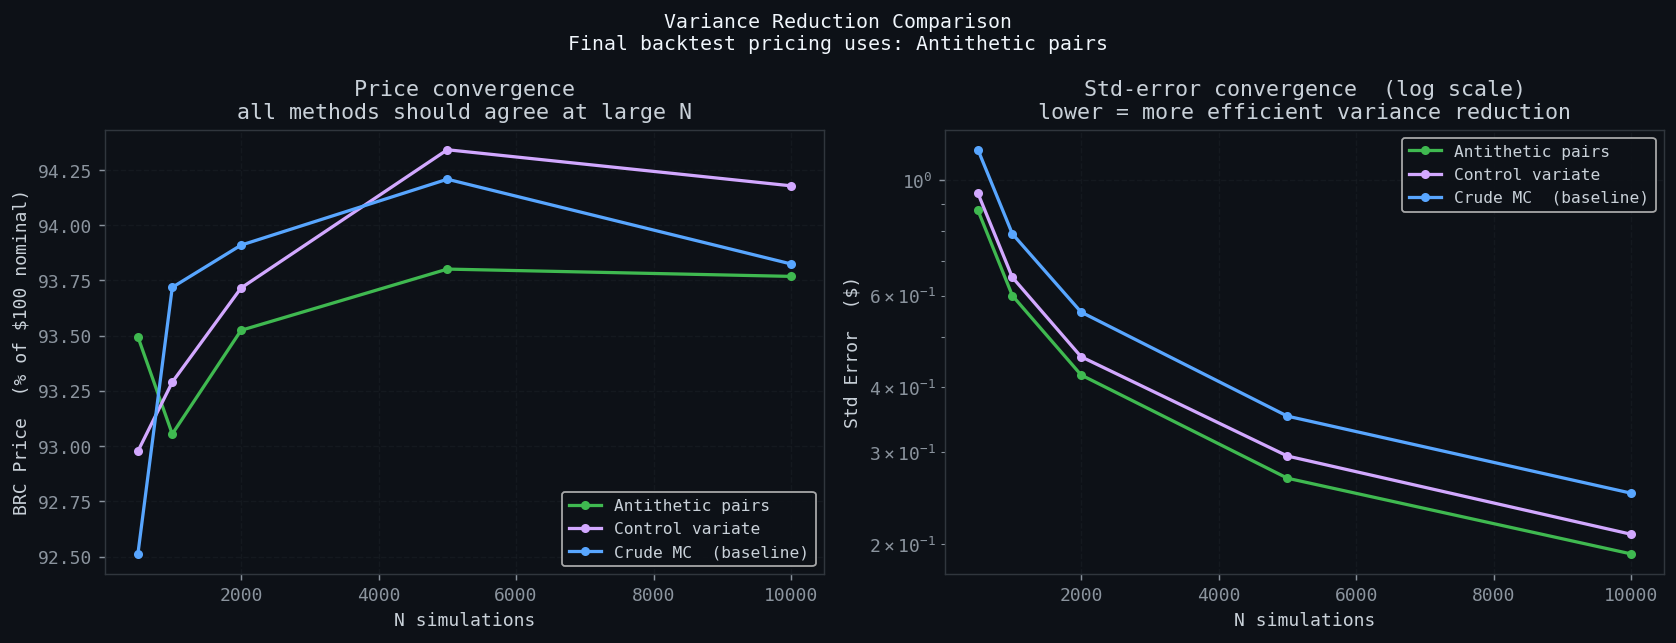

In [10]:
plot_vr_convergence(vr_df)


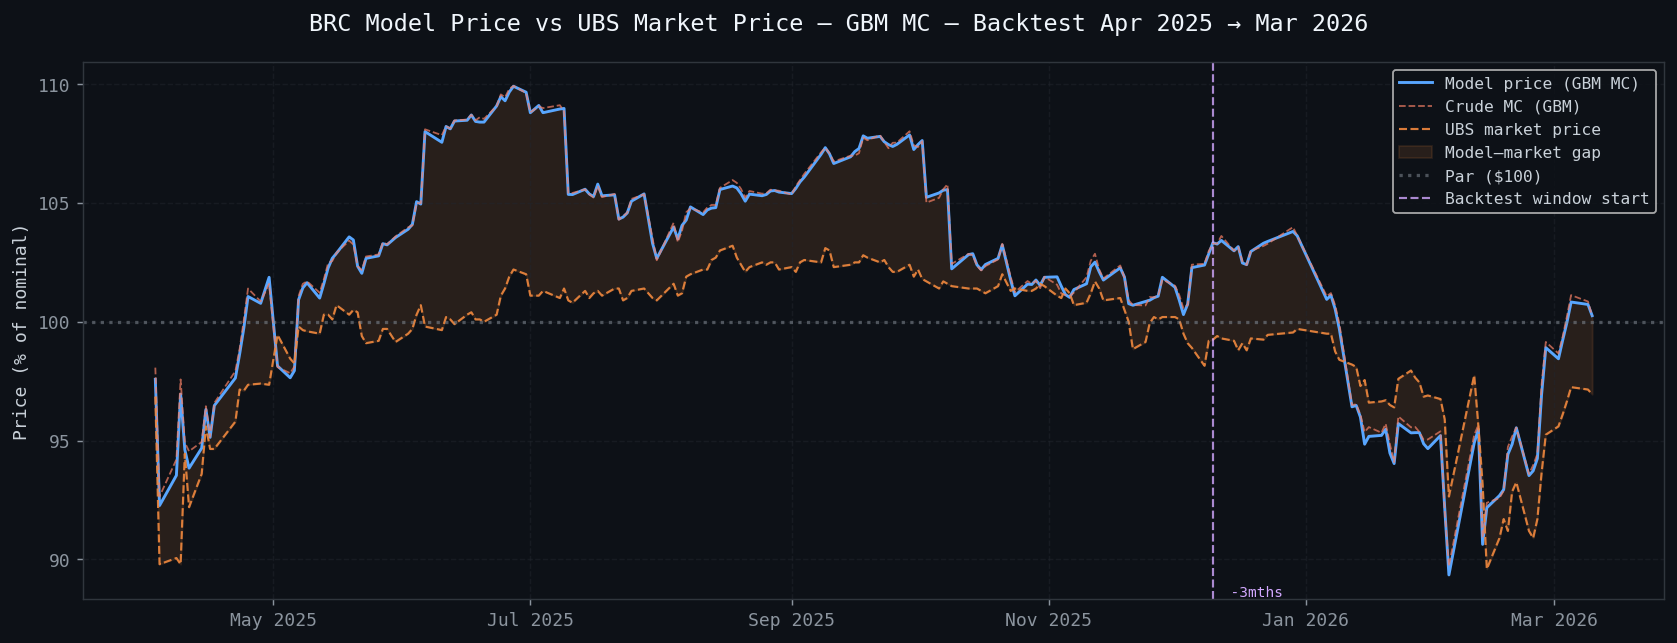

In [11]:
plot_backtest_price(backtest_result,
                    realised_spots        = ds.realised_spots,
                    tickers               = TICKERS,
                    fixing                = fixing,
                    barrier_level         = BRC_TERMS["barrier_level"],
                    historical_brc_prices = ds.historical_brc_prices
                                            if not ds.historical_brc_prices.empty
                                            else None,
                    model_name            = Simulator.model_name())

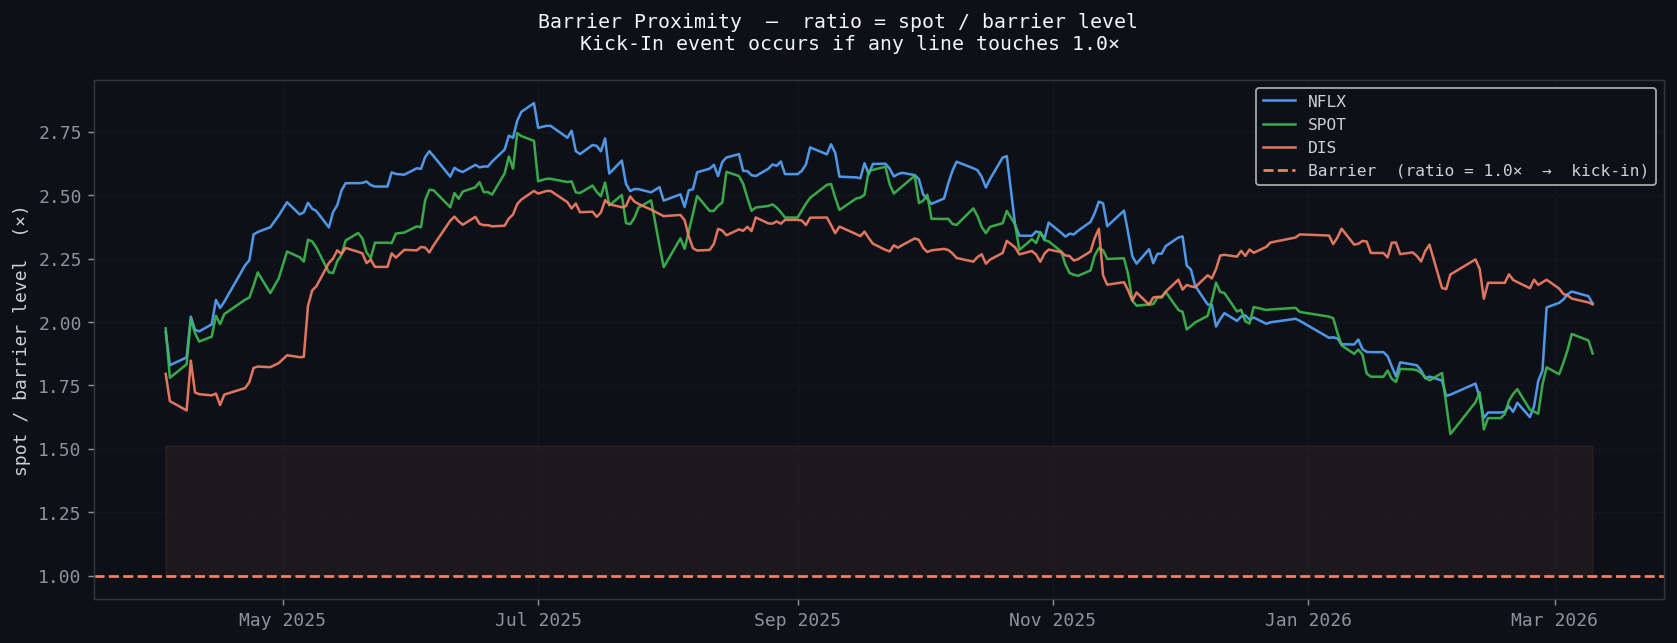

In [12]:
plot_barrier_proximity(backtest_result, TICKERS)


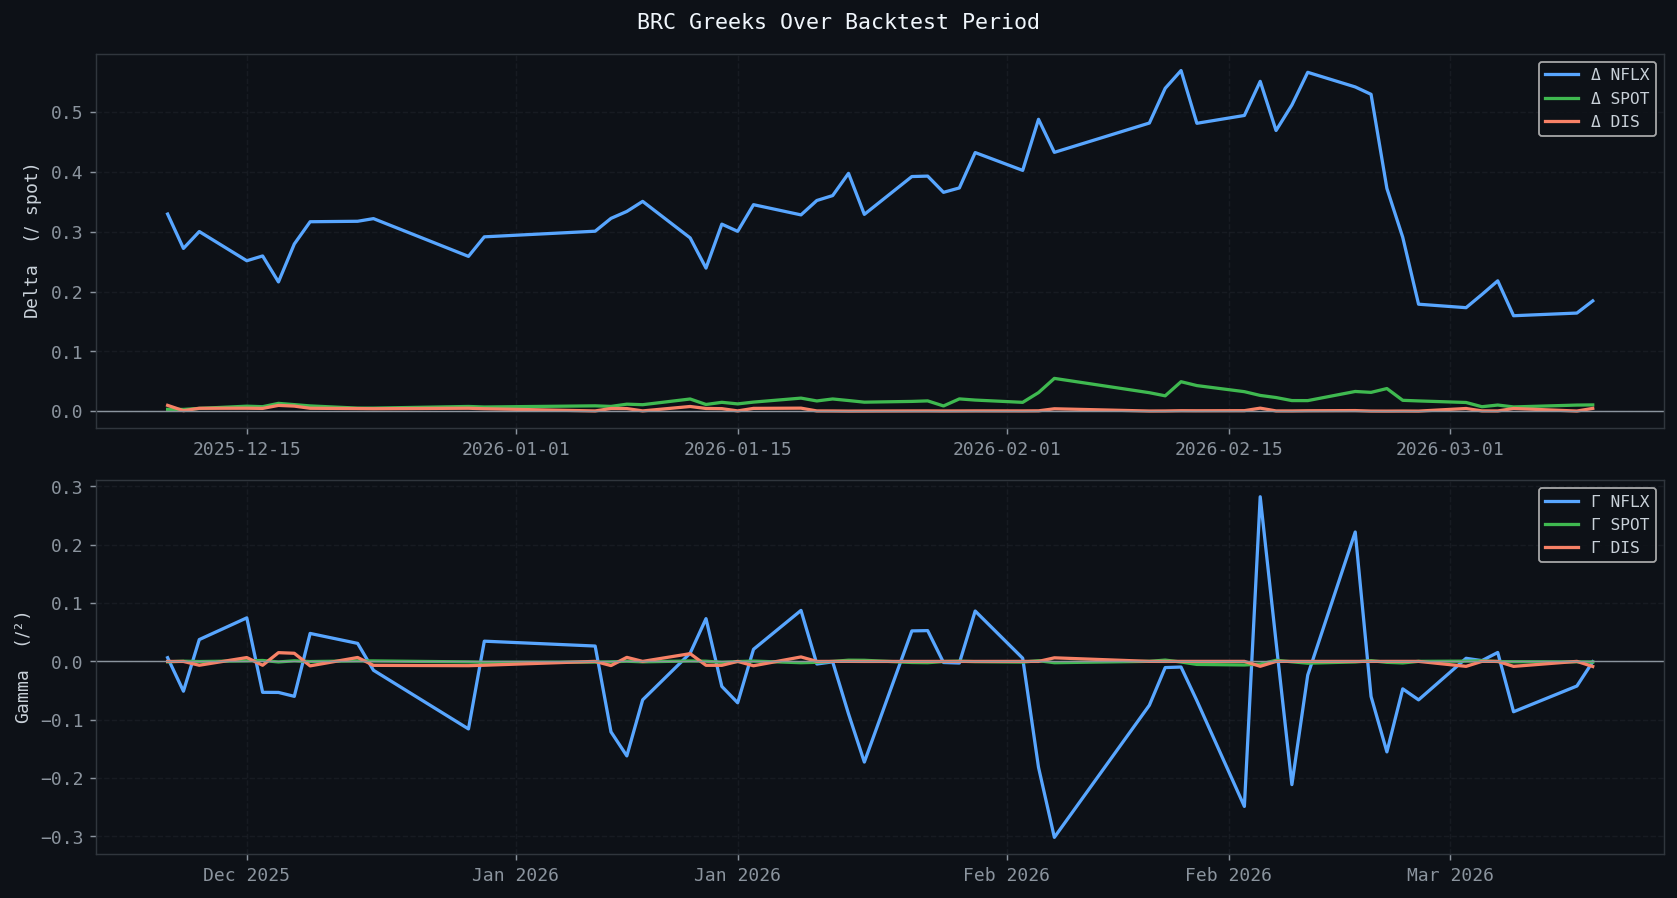

In [13]:
plot_greeks(backtest_result, TICKERS)


In [14]:
write_validation_report(
    backtest_result       = backtest_result,
    inception_params      = ds.model_params,
    terminal_params       = blended_terminal if blended_terminal else ds.terminal_model_params,
    tickers               = TICKERS,
    historical_brc_prices = ds.historical_brc_prices
                            if not ds.historical_brc_prices.empty else None,
    model_name            = Simulator.model_name(),
)

vr_path = f"./results/vr_comparison.csv"
vr_df.to_csv(vr_path, index=False)
print(f"\n  VR comparison table saved to {vr_path}")

print("\n" + "="*60)
print("PIPELINE COMPLETE")
print("="*60)
print(f"  Model     : {Simulator.model_name()}")
print(f"  Outputs in ./results/")


  Validation report saved to ./results/validation_report.txt

BRC MODEL -- VALIDATION REPORT

BACKTEST PRICE SERIES
----------------------------------------
  Date grid       : aligned to historical UBS prices where available
  N pricing dates : 217
  Inception price : 97.5786
  Latest price    : 100.2573
  Min price       : 89.3504  (2026-02-04)
  Max price       : 109.9095  (2025-06-27)

  MODEL (w/o antithetic) vs UBS MARKET PRICE  (errors in % of $100 nominal)
  Window                 N     MAE    RMSE    Bias   MaxErr
  -------------------------------------------------------
  Full period          217    3.21    3.85  + 2.83     8.78
  Last 6 months        115    2.48    2.94  + 1.79     5.80
  Last 3 months         54    2.65    2.86  + 1.22     4.43

  MODEL (with antithetic) vs UBS MARKET PRICE  (errors in % of $100 nominal)
  Window                 N     MAE    RMSE    Bias   MaxErr
  -------------------------------------------------------
  Full period          217    3.17  

In [11]:
model_name         = "gbm"
surface_type       = "bs"
surface_csv        = None
data_root          = None
backtest_frequency = "W"
n_sims_main        = N_SIMS_MAIN

if surface_csv:
    print(f"\n  Surface CSV (explicit): {surface_csv}")
    surf_df, inferred_type = load_surface_from_path(surface_csv)

    ds = DataStore()
    ds.surface_type     = inferred_type
    ds.inception_surface = surf_df
    paths_ = resolve_paths(data_root)

    try:
        ds.log_returns        = load_log_returns(paths_["log_returns"])
        ds.correlation_matrix = estimate_correlation(ds.log_returns)
    except Exception:
        print("  Using hardcoded correlation.")
        ds.correlation_matrix = np.array([
            [1.000, 0.357, 0.352],
            [0.357, 1.000, 0.489],
            [0.352, 0.489, 1.000],
        ])

    
    ds.realised_spots        = fetch_realised_prices()

In [12]:
ds.realised_spots

NameError: name 'ds' is not defined

In [13]:
print(f"\n  Surface type : {surface_type.upper()} (synthetic fallback)")
ds = build_data_store(
    simulator_class = Simulator,
    surface_type    = surface_type,
    data_root       = data_root,
)


  Surface type : BS (synthetic fallback)

STAGE I — DATA COLLECTION

[Log returns — correlation window]
  Log returns: 1317 obs, tickers=['NFLX', 'SPOT', 'DIS']

[Inception surface]
  [NFLX] Split-adjustment detected: dividing strikes by 10.
  [NFLX] Historical option chain: 57 IV points  (from C:\Users\ezrak\MH4518_Group8\final_dataset\historical_option\NFLX.csv)
  [SPOT] No historical_option CSV found — will use synthetic surface.
  [DIS] Historical option chain: 40 IV points  (from C:\Users\ezrak\MH4518_Group8\final_dataset\historical_option\DIS.csv)
  Historical surface (combined): 97 IV points
  Tickers missing from historical_option/: ['SPOT']
  Surface [bs]: 189 rows, 3 tickers

[Realised prices — BRC life]
  Fetching realised prices 2024-04-02 to 2026-04-14 ...
  Realised prices: 509 trading days
  Initial fixing prices (termsheet): {'NFLX': 93.55, 'SPOT': 565.41, 'DIS': 97.88}

[Live option chain — today]
  [NFLX] 20 expiries available
  [SPOT] 18 expiries available
  [DIS] 1

In [14]:
ds.realised_spots

Ticker,NFLX,SPOT,DIS
Date,,,
2024-04-02,61.421001,269.579987,120.385277
2024-04-03,63.007999,291.769989,116.621399
2024-04-04,61.714001,295.959991,114.768860
2024-04-05,63.618000,310.309998,116.033302
2024-04-08,62.841000,309.070007,115.023712
...,...,...,...
2026-04-07,98.820000,483.179993,95.779999
2026-04-08,99.389999,483.170013,99.180000
2026-04-09,102.050003,486.619995,99.790001


<Axes: xlabel='Date'>

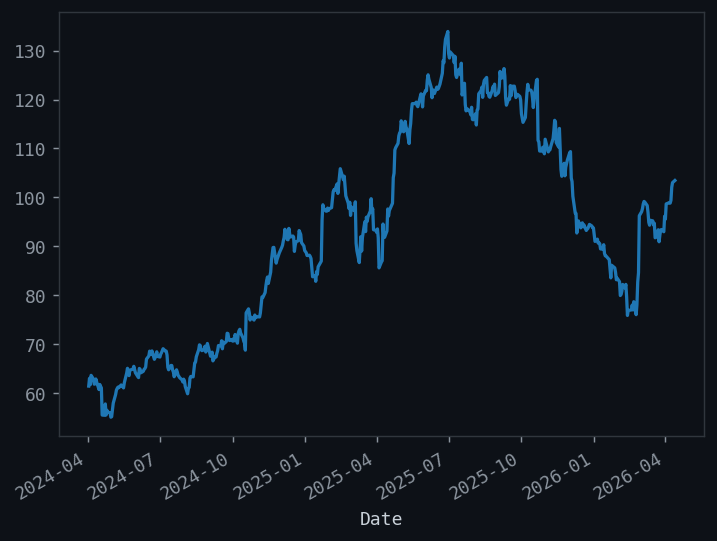

In [15]:
ds.realised_spots['NFLX'].plot()